In [1]:
# ===== Cell 1: setup & config =====
import os, json, re, collections, math, random
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import torchvision.transforms as T

# Repro
SEED = 1337
random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---- Paths (EDIT if needed) ----
ROOT = "PartImageNet_Seg/PartImageNet"                 # folder containing 'annotations' and 'images'
TRAIN_ANN = "annotations/train/train.json"
TEST_ANN  = "annotations/test/test.json"
# (Optional) VAL_ANN if you have it
VAL_ANN   = "annotations/val/val.json"

TRAIN_IMG_ROOT = "images/train"
TEST_IMG_ROOT  = "images/test"
VAL_IMG_ROOT   = "images/val"

# ---- AlexNet / ImageNet transforms ----
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.Resize(256),
    T.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.8, 1.2)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Minimum crop size in pixels (width/height); use 12+ to skip tiny boxes
MIN_SIZE = 12


Device: cuda


In [2]:
# ===== Cell 2: dataset, global clusters, loaders =====

FILE_KEYS  = ["file_name","fileName","path","image","name"]
CATID_KEYS = ["category_id","categoryId","object_category_id","obj_cat"]
BBOX_KEYS  = ["bbox","bBox","box"]
SEG_KEYS   = ["segmentation","seg","polygon"]

def _find_any(d, keys):
    for k in keys:
        if k in d: return d[k]
    return None

def _derive_part_from_category_name(cat_name: str) -> str:
    if not cat_name: return "misc"
    s = re.sub(r"[-_]+", " ", str(cat_name).strip().lower())
    toks = s.split()
    return toks[-1] if toks else "misc"

def _box_from_poly(poly):
    xs = poly[0::2]; ys = poly[1::2]
    return [float(min(xs)), float(min(ys)), float(max(xs)-min(xs)), float(max(ys)-min(ys))]

def pil_crop_from_ann(img: Image.Image, ann: dict):
    bx = _find_any(ann, BBOX_KEYS)
    if bx is None:
        seg = _find_any(ann, SEG_KEYS)
        if seg and isinstance(seg, list) and len(seg) > 0:
            poly = seg[0] if isinstance(seg[0], list) else seg
            bx = _box_from_poly(poly)
        else:
            return None
    if isinstance(bx, dict):
        x,y,w,h = float(bx.get("x",0)), float(bx.get("y",0)), float(bx.get("width",0)), float(bx.get("height",0))
    else:
        x,y,w,h = map(float, bx)
    x0, y0 = int(max(0, x)), int(max(0, y))
    x1, y1 = int(min(img.width, x+w)), int(min(img.height, y+h))
    if x1 <= x0 or y1 <= y0: return None
    return img.crop((x0, y0, x1, y1))

def resolve_path(root: str, images_root: str, fn: str) -> Optional[str]:
    base = Path(root)
    imroot = base / images_root if images_root else base
    candidates = [
        imroot / fn,
        imroot / "jpegs" / fn,
        base / fn,
    ]
    for p in candidates:
        if p.exists(): return str(p)
    return None

def build_global_clusters(root: str, ann_paths: List[str]) -> Dict[str, List[str]]:
    """part_token -> sorted list of ORIGINAL category names (global vocab across splits)"""
    by_part = collections.defaultdict(set)
    for rel in ann_paths:
        p = os.path.join(root, rel)
        if not os.path.exists(p): continue
        J = json.load(open(p, "r"))
        for c in J.get("categories", []):
            nm = str(c.get("name","")).strip()
            if not nm: continue
            by_part[_derive_part_from_category_name(nm)].add(nm)
    return {part: sorted(names) for part, names in by_part.items()}

GLOBAL_CLUSTERS = build_global_clusters(ROOT, [TRAIN_ANN, TEST_ANN, VAL_ANN])
CANONICAL_PARTS = sorted(GLOBAL_CLUSTERS.keys())
PART_TO_IDX = {p:i for i,p in enumerate(CANONICAL_PARTS)}
print("Discovered parts:", CANONICAL_PARTS)

class PartExample:
    def __init__(self, img_path, part_canonical, cluster_name, bbox_or_seg_ann, image_id):
        self.img_path = img_path
        self.part_canonical = part_canonical   # e.g., "wing", "tier", "head"
        self.cluster_name = cluster_name       # original category name, e.g., "Bird Wing"
        self.bbox_or_seg_ann = bbox_or_seg_ann
        self.image_id = image_id

class PartCropDataset2(Dataset):
    """
    Crops RGB from bbox or polygon; routes by last token of category name (data-driven parts).
    Clusters are ORIGINAL category names, but indices are from a GLOBAL map (consistent across splits).
    """
    def __init__(self, root: str, json_path: str, images_root: str, transform=None, min_size: int = 12, global_clusters=None):
        super().__init__()
        self.root, self.images_root = root, images_root
        self.transform = transform or eval_tf
        self.min_size = min_size
        self.global_clusters = global_clusters or GLOBAL_CLUSTERS

        J = json.load(open(os.path.join(root, json_path), "r"))
        self.cat_map = {int(c["id"]): c for c in J.get("categories", []) if "id" in c}

        # image_id -> resolved file path
        self.image_map = {}
        for im in J.get("images", []):
            fn = _find_any(im, FILE_KEYS)
            if not fn: continue
            im_id = im.get("id", im.get("image_id", len(self.image_map)))
            full = resolve_path(root, images_root, fn)
            if full: self.image_map[im_id] = full

        # items
        items = []
        miss_path = miss_cat = tiny_box = 0
        for a in J.get("annotations", []):
            img_id = a.get("image_id", a.get("id"))
            full = self.image_map.get(img_id)
            if not full or not os.path.exists(full): miss_path += 1; continue

            cid = _find_any(a, CATID_KEYS)
            cat = self.cat_map.get(int(cid), {}) if cid is not None else {}
            cat_name = cat.get("name"); supercat = cat.get("supercategory")
            if not cat_name and not supercat: miss_cat += 1; continue

            part = _derive_part_from_category_name(cat_name)
            cluster_name = cat_name or supercat or str(cid)

            # filter tiny boxes if bbox present
            bx = _find_any(a, BBOX_KEYS)
            if bx is not None:
                if isinstance(bx, dict):
                    w = float(bx.get("width", 0)); h = float(bx.get("height", 0))
                else:
                    try:
                        _,_,w,h = bx
                        w,h = float(w), float(h)
                    except Exception:
                        w = h = 0
                if (w < self.min_size) or (h < self.min_size):
                    tiny_box += 1; continue

            items.append(PartExample(full, part, str(cluster_name), a, img_id))

        self.items: List[PartExample] = items

        # Build detector_clusters with the provided global order
        self.detector_clusters: Dict[str, Dict[str,int]] = {
            p: {name:i for i, name in enumerate(self.global_clusters.get(p, []))}
            for p in CANONICAL_PARTS
        }

        # Count OOV (cluster names present in items but not in global map)
        self.oov_counts = {}
        for it in self.items:
            if it.cluster_name not in self.detector_clusters.get(it.part_canonical, {}):
                self.oov_counts[it.part_canonical] = self.oov_counts.get(it.part_canonical, 0) + 1

        print(f"[PartCropDataset2] images={len(self.image_map)} items={len(self.items)} "
              f"miss_path={miss_path} miss_cat={miss_cat} tiny_box={tiny_box}")
        if self.oov_counts:
            print("OOV cluster labels found (ignored at __getitem__):", self.oov_counts)

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        it = self.items[idx]
        img = Image.open(it.img_path).convert("RGB")
        crop = pil_crop_from_ann(img, it.bbox_or_seg_ann)
        if crop is None:
            # fallback black chip (should be rare)
            crop = Image.new("RGB", (224,224), (0,0,0))
        x = self.transform(crop)

        det_idx = PART_TO_IDX.get(it.part_canonical, 0)
        cluster_idx = self.detector_clusters.get(it.part_canonical, {}).get(it.cluster_name, -1)
        return x, det_idx, cluster_idx, it.image_id

# ---- Instantiate datasets ----
ds_tr = PartCropDataset2(ROOT, TRAIN_ANN, TRAIN_IMG_ROOT, transform=train_tf, min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)
ds_val = PartCropDataset2(ROOT, VAL_ANN,   VAL_IMG_ROOT,   transform=eval_tf,   min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)
ds_te = PartCropDataset2(ROOT, TEST_ANN,  TEST_IMG_ROOT,  transform=eval_tf,   min_size=MIN_SIZE, global_clusters=GLOBAL_CLUSTERS)

print("num part-crops (train):", len(ds_tr))
print("num part-crops (val):  ", len(ds_val))
print("num part-crops (test): ", len(ds_te))
print("parts:", CANONICAL_PARTS)
for p in CANONICAL_PARTS:
    print(f"{p:10s} -> {len(ds_tr.detector_clusters[p])} classes")


Discovered parts: ['body', 'engine', 'fin', 'foot', 'hand', 'head', 'mirror', 'mouth', 'sail', 'seat', 'tail', 'tier', 'wing']
[PartCropDataset2] images=20466 items=90451 miss_path=0 miss_cat=0 tiny_box=4608
[PartCropDataset2] images=1206 items=5306 miss_path=0 miss_cat=0 tiny_box=320
[PartCropDataset2] images=2408 items=10715 miss_path=0 miss_cat=0 tiny_box=560
num part-crops (train): 90451
num part-crops (val):   5306
num part-crops (test):  10715
parts: ['body', 'engine', 'fin', 'foot', 'hand', 'head', 'mirror', 'mouth', 'sail', 'seat', 'tail', 'tier', 'wing']
body       -> 11 classes
engine     -> 1 classes
fin        -> 1 classes
foot       -> 4 classes
hand       -> 1 classes
head       -> 8 classes
mirror     -> 1 classes
mouth      -> 1 classes
sail       -> 1 classes
seat       -> 1 classes
tail       -> 6 classes
tier       -> 2 classes
wing       -> 2 classes


In [ ]:
from part_detector_refactor import train_shared_multihead, PartEnsembleShared

shared_ckpt_dir = "shared_resnet50_ckpt"

train_shared_multihead(
    ds_train=ds_tr,
    ds_val=ds_te,
    outdir=shared_ckpt_dir,
    emb_dim=128,
    epochs=150,                        # longer helps from-scratch
    batch_size=128,                    # adjust for memory
    lr=8e-4,                           # good AdamW starting point
    backbone="resnet50",
    backbone_trainable=True,
    weights=None,                      # <-- RANDOM INIT (from scratch)
    # CUDA & perf
    device="cuda", use_amp=True, use_tf32=True, channels_last=True, use_compile=False,
    num_workers=8, prefetch_factor=2, persistent_workers=True,
    # Regularization
    weight_decay=0.05,                 # stronger WD for scratch
    norm_weight_decay=0.0,             # no WD on norm params
    bias_weight_decay=0.0,             # no WD on biases
    # Scheduler
    scheduler_type="cosine",           # cosine anneal
    warmup_epochs=5                   # linear warmup
)

ens_shared = PartEnsembleShared(shared_ckpt_dir, device="cuda")


/home/dfli/full_hyco/part_detector_refactor.py:1022: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type=="cuda"))
/home/dfli/full_hyco/part_detector_refactor.py:1037: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler.is_enabled())):
/home/dfli/full_hyco/part_detector_refactor.py:1055: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(scaler.is_enabled())):


[shared:resnet50] ep 01/150  tr_loss=8.2490 tr_acc=0.660  val_loss=9.3067 val_acc=0.160  lr=1.61e-04
[shared:resnet50] ep 02/150  tr_loss=6.3466 tr_acc=0.726  val_loss=10.0726 val_acc=0.259  lr=3.20e-04
[shared:resnet50] ep 03/150  tr_loss=5.6877 tr_acc=0.761  val_loss=9.5344 val_acc=0.302  lr=4.80e-04
[shared:resnet50] ep 04/150  tr_loss=5.4169 tr_acc=0.777  val_loss=8.6875 val_acc=0.342  lr=6.40e-04


/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


[shared:resnet50] ep 05/150  tr_loss=5.1443 tr_acc=0.788  val_loss=8.6285 val_acc=0.363  lr=8.00e-04
[shared:resnet50] ep 06/150  tr_loss=5.0447 tr_acc=0.796  val_loss=9.1352 val_acc=0.348  lr=8.00e-04
[shared:resnet50] ep 07/150  tr_loss=4.7384 tr_acc=0.812  val_loss=8.5343 val_acc=0.367  lr=8.00e-04
[shared:resnet50] ep 08/150  tr_loss=4.5528 tr_acc=0.823  val_loss=8.4545 val_acc=0.399  lr=7.99e-04
[shared:resnet50] ep 09/150  tr_loss=4.4264 tr_acc=0.830  val_loss=8.1810 val_acc=0.413  lr=7.98e-04
[shared:resnet50] ep 10/150  tr_loss=4.3583 tr_acc=0.835  val_loss=8.1134 val_acc=0.410  lr=7.98e-04
[shared:resnet50] ep 11/150  tr_loss=4.1382 tr_acc=0.845  val_loss=8.1645 val_acc=0.420  lr=7.97e-04
[shared:resnet50] ep 12/150  tr_loss=4.0850 tr_acc=0.849  val_loss=8.1571 val_acc=0.437  lr=7.95e-04
[shared:resnet50] ep 13/150  tr_loss=3.9545 tr_acc=0.858  val_loss=7.8936 val_acc=0.451  lr=7.94e-04
[shared:resnet50] ep 14/150  tr_loss=3.9112 tr_acc=0.860  val_loss=8.1522 val_acc=0.445  lr

In [5]:
from part_detector_refactor import train_alex_detectors_revised

train_alex_detectors_revised(
    ds_train=ds_tr,
    ds_val=ds_val,                 # or None
    outdir="alex_ckpts_revised",
    emb_dim=128,
    epochs=90,
    batch_size=512,
    weights=None,
    num_workers=8, prefetch_factor=4, persistent_workers=True,
    channels_last=True, use_tf32=True, use_amp=True,
    # make early stopping use the balanced acc:
    val_metric='cluster_balanced',
)

[body] ep 01/90  tr_loss=2.0863 tr_acc=0.105  val_loss=2.9748 val_acc_raw=0.026 val_acc_bal=0.142  lr=3.00e-04
[body] ep 02/90  tr_loss=1.7769 tr_acc=0.180  val_loss=2.8797 val_acc_raw=0.039 val_acc_bal=0.179  lr=3.00e-04
[body] ep 03/90  tr_loss=1.5628 tr_acc=0.233  val_loss=2.7128 val_acc_raw=0.052 val_acc_bal=0.191  lr=3.00e-04
[body] ep 04/90  tr_loss=1.4677 tr_acc=0.266  val_loss=2.7172 val_acc_raw=0.061 val_acc_bal=0.209  lr=3.00e-04
[body] ep 05/90  tr_loss=1.3544 tr_acc=0.309  val_loss=2.5460 val_acc_raw=0.090 val_acc_bal=0.227  lr=3.00e-04


Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78778599f2e0><function _MultiProcessingDataLoaderIter.__del__ at 0x78778599f2e0><function _MultiProcessingDataLoaderIter.__del__ at 0x78778599f2e0>
<function _MultiProcessingDataLoaderIter.__del__ at 0x78778599f2e0>
Traceback (most recent call last):


Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
Traceback (most recent call last):
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
Exception ignored in:   File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/utils/data/dataloader.p

[body] ep 06/90  tr_loss=1.2536 tr_acc=0.358  val_loss=2.4278 val_acc_raw=0.160 val_acc_bal=0.299  lr=3.00e-04


Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78778599f2e0><function _MultiProcessingDataLoaderIter.__del__ at 0x78778599f2e0>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
        if w.is_alive():
if w.is_alive(): 
           ^^ ^ ^^^^^^^^^^^^^^^^^^
^  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/multiprocessing/process.py", lin

[body] ep 07/90  tr_loss=1.1651 tr_acc=0.410  val_loss=2.3600 val_acc_raw=0.198 val_acc_bal=0.306  lr=3.00e-04
[body] ep 08/90  tr_loss=1.1055 tr_acc=0.452  val_loss=2.2833 val_acc_raw=0.242 val_acc_bal=0.387  lr=3.00e-04
[body] ep 09/90  tr_loss=1.0538 tr_acc=0.485  val_loss=2.3243 val_acc_raw=0.239 val_acc_bal=0.371  lr=3.00e-04
[body] ep 10/90  tr_loss=0.9877 tr_acc=0.522  val_loss=2.3262 val_acc_raw=0.240 val_acc_bal=0.379  lr=3.00e-04
[body] ep 11/90  tr_loss=0.9503 tr_acc=0.533  val_loss=2.2269 val_acc_raw=0.296 val_acc_bal=0.407  lr=3.00e-04
[body] ep 12/90  tr_loss=0.9136 tr_acc=0.562  val_loss=2.2860 val_acc_raw=0.272 val_acc_bal=0.388  lr=3.00e-04
[body] ep 13/90  tr_loss=0.8912 tr_acc=0.575  val_loss=2.2970 val_acc_raw=0.285 val_acc_bal=0.416  lr=3.00e-04
[body] ep 14/90  tr_loss=0.8609 tr_acc=0.591  val_loss=2.2221 val_acc_raw=0.297 val_acc_bal=0.425  lr=3.00e-04
[body] ep 15/90  tr_loss=0.8342 tr_acc=0.603  val_loss=2.1374 val_acc_raw=0.335 val_acc_bal=0.454  lr=3.00e-04
[

...

[fin] ep 90/90  s=0.0618  tr_loss=0.0150 tr_acc=N/A  val_loss=0.0185 (s_val=0.0559)  val_oc_auc=0.509 val_oc_bacc=0.534  lr=1.83e-08


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78778599f2e0>
Traceback (most recent call last):
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
    Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x78778599f2e0> 
 Traceback (most recent call last):
^  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
^    ^self._shutdown_workers()^
^^  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ 
    File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/multiprocessing/process.py", line 160, in is_

[foot] ep 01/90  tr_loss=1.1581 tr_acc=0.306  val_loss=1.8919 val_acc_raw=0.112 val_acc_bal=0.163  lr=3.00e-04
[foot] ep 02/90  tr_loss=1.0700 tr_acc=0.357  val_loss=1.8709 val_acc_raw=0.126 val_acc_bal=0.187  lr=3.00e-04
[foot] ep 03/90  tr_loss=1.0241 tr_acc=0.378  val_loss=1.7460 val_acc_raw=0.146 val_acc_bal=0.225  lr=3.00e-04
[foot] ep 04/90  tr_loss=0.9567 tr_acc=0.422  val_loss=1.7564 val_acc_raw=0.192 val_acc_bal=0.260  lr=3.00e-04
[foot] ep 05/90  tr_loss=0.9253 tr_acc=0.457  val_loss=1.7229 val_acc_raw=0.187 val_acc_bal=0.250  lr=3.00e-04
[foot] ep 06/90  tr_loss=0.8844 tr_acc=0.477  val_loss=1.6279 val_acc_raw=0.225 val_acc_bal=0.295  lr=3.00e-04
[foot] ep 07/90  tr_loss=0.8671 tr_acc=0.491  val_loss=1.6759 val_acc_raw=0.212 val_acc_bal=0.280  lr=3.00e-04
[foot] ep 08/90  tr_loss=0.8337 tr_acc=0.507  val_loss=1.6156 val_acc_raw=0.225 val_acc_bal=0.294  lr=3.00e-04
[foot] ep 09/90  tr_loss=0.8130 tr_acc=0.526  val_loss=1.6269 val_acc_raw=0.231 val_acc_bal=0.299  lr=3.00e-04
[

Traceback (most recent call last):
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/multiprocessing/util.py", line 227, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/multiprocessing/util.py", line 136, in _remove_temp_dir
    rmtree(tempdir, onerror=onerror)
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/shutil.py", line 759, in rmtree
    _rmtree_safe_fd(stack, onexc)
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/shutil.py", line 703, in _rmtree_safe_fd
    onexc(func, path, err)
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12/shutil.py", line 750, in onexc
    return onerror(func, path, exc_info)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dfli/anaconda3/envs/partviz/lib/python3.12

[hand] ep 86/90  s=0.0610  tr_loss=0.0155 tr_acc=N/A  val_loss=0.0196 (s_val=0.0548)  val_oc_auc=0.457 val_oc_bacc=0.525  lr=1.83e-08
[hand] ep 87/90  s=0.0611  tr_loss=0.0155 tr_acc=N/A  val_loss=0.0196 (s_val=0.0548)  val_oc_auc=0.431 val_oc_bacc=0.512  lr=1.83e-08
[hand] ep 88/90  s=0.0610  tr_loss=0.0155 tr_acc=N/A  val_loss=0.0196 (s_val=0.0548)  val_oc_auc=0.434 val_oc_bacc=0.511  lr=1.83e-08
[hand] ep 89/90  s=0.0611  tr_loss=0.0155 tr_acc=N/A  val_loss=0.0196 (s_val=0.0548)  val_oc_auc=0.436 val_oc_bacc=0.514  lr=1.83e-08
[hand] ep 90/90  s=0.0610  tr_loss=0.0155 tr_acc=N/A  val_loss=0.0196 (s_val=0.0548)  val_oc_auc=0.405 val_oc_bacc=0.506  lr=1.83e-08
[head] ep 01/90  tr_loss=1.9532 tr_acc=0.130  val_loss=2.5017 val_acc_raw=0.010 val_acc_bal=0.067  lr=3.00e-04
[head] ep 02/90  tr_loss=1.4489 tr_acc=0.162  val_loss=2.2071 val_acc_raw=0.153 val_acc_bal=0.225  lr=3.00e-04
[head] ep 03/90  tr_loss=1.2886 tr_acc=0.213  val_loss=2.0583 val_acc_raw=0.181 val_acc_bal=0.323  lr=3.00e-

In [6]:
import json, os
from collections import Counter

# Set paths
ROOT = "PartImageNet_Seg/PartImageNet"
TRAIN_JSON = "annotations/train/train.json"
train_json_path = TRAIN_JSON if os.path.isabs(TRAIN_JSON) else os.path.join(ROOT, TRAIN_JSON)

def read_coco(path): 
    with open(path, "r") as f: 
        return json.load(f)

def build_super_maps(train_json_path):
    data = read_coco(train_json_path)
    supers = sorted({c["supercategory"] for c in data["categories"]})
    super_to_idx = {s: i for i, s in enumerate(supers)}        # 11-way
    name_to_super = {c["name"]: c["supercategory"] for c in data["categories"]}  # "Quadruped Head" -> "Quadruped"
    return super_to_idx, name_to_super

SUPER_TO_IDX, NAME_TO_SUPER = build_super_maps(train_json_path)
print("11-way superclasses:", list(SUPER_TO_IDX.keys()))


11-way superclasses: ['Aeroplane', 'Bicycle', 'Biped', 'Bird', 'Boat', 'Bottle', 'Car', 'Fish', 'Quadruped', 'Reptile', 'Snake']


In [7]:
SUPERS_LOWER = {s.lower(): s for s in SUPER_TO_IDX.keys()}

def to_super_name(cluster_name: str):
    # First, exact match via the COCO categories map (best)
    if cluster_name in NAME_TO_SUPER:
        return NAME_TO_SUPER[cluster_name]
    # Fallback: substring heuristic (handles "Bird Wing k=7", "Quadruped Body 3", etc.)
    low = cluster_name.lower()
    for low_super, canonical in SUPERS_LOWER.items():
        if low_super in low:
            return canonical
    return None  # unmapped -> ignore


In [8]:
def build_global_clusters(root: str, ann_paths: List[str]) -> Dict[str, List[str]]:
    """part_token -> sorted list of ORIGINAL category names (global vocab across splits)"""
    by_part = collections.defaultdict(set)
    for rel in ann_paths:
        p = os.path.join(root, rel)
        if not os.path.exists(p): continue
        J = json.load(open(p, "r"))
        for c in J.get("categories", []):
            nm = str(c.get("name","")).strip()
            if not nm: continue
            by_part[_derive_part_from_category_name(nm)].add(nm)
    return {part: sorted(names) for part, names in by_part.items()}

# GLOBAL_CLUSTERS is your canonical global label mapping (name -> id)
# If you don't have one, use the union of train-side cluster names:
GLOBAL_CLUSTERS = {name: i for i, name in enumerate(
    sorted({n for n in ds_tr.detector_clusters for n in ds_tr.detector_clusters[n]})
)}

# Parts list (stable order) and per-part inverse maps: local_idx -> cluster_name
PARTS = list(ds_tr.detector_clusters.keys())
INV_LOCAL = {p: {v: k for k, v in ds_tr.detector_clusters[p].items()} for p in PARTS}
GLOBAL_CLUSTERS

{'Aeroplane Body': 0,
 'Aeroplane Engine': 1,
 'Aeroplane Head': 2,
 'Aeroplane Tail': 3,
 'Aeroplane Wing': 4,
 'Bicycle Body': 5,
 'Bicycle Head': 6,
 'Bicycle Seat': 7,
 'Bicycle Tier': 8,
 'Biped Body': 9,
 'Biped Foot': 10,
 'Biped Hand': 11,
 'Biped Head': 12,
 'Biped Tail': 13,
 'Bird Body': 14,
 'Bird Foot': 15,
 'Bird Head': 16,
 'Bird Tail': 17,
 'Bird Wing': 18,
 'Boat Body': 19,
 'Boat Sail': 20,
 'Bottle Body': 21,
 'Bottle Mouth': 22,
 'Car Body': 23,
 'Car Side Mirror': 24,
 'Car Tier': 25,
 'Fish Body': 26,
 'Fish Fin': 27,
 'Fish Head': 28,
 'Fish Tail': 29,
 'Quadruped Body': 30,
 'Quadruped Foot': 31,
 'Quadruped Head': 32,
 'Quadruped Tail': 33,
 'Reptile Body': 34,
 'Reptile Foot': 35,
 'Reptile Head': 36,
 'Reptile Tail': 37,
 'Snake Body': 38,
 'Snake Head': 39}

In [9]:
from torch.utils.data import Dataset
import numbers

_BAD = object()  # sentinel to skip bad items safely

class FuserView(Dataset):
    """
    Wraps your existing dataset to ensure what gets sent from worker -> main
    is picklable and minimal. It returns (x, det_idx, local_idx, part_hint)
    where part_hint is a small string or None (never a complex object).
    """
    def __init__(self, base_ds, debug=False):
        self.base = base_ds
        self.debug = debug

    def __len__(self): 
        return len(self.base)

    def __getitem__(self, i):
        try:
            item = self.base[i]
            if not isinstance(item, (list, tuple)) or len(item) < 3:
                # unexpected shape
                return _BAD

            # unpack common shapes
            if len(item) >= 4:
                x, det_idx, y_local, meta = item[:4]
            else:
                x, det_idx, y_local = item[:3]
                meta = None

            # Make a tiny, picklable "part hint" if available
            part_hint = None
            if isinstance(meta, dict):
                part_hint = meta.get('part_canonical') or meta.get('part') or meta.get('part_name')
            else:
                # try attribute access but cast to str to keep it picklable
                for k in ('part_canonical', 'part', 'part_name'):
                    if hasattr(meta, k):
                        val = getattr(meta, k)
                        if isinstance(val, str):
                            part_hint = val
                        break

            # det_idx should be small/int/str only
            if not (isinstance(det_idx, (numbers.Integral, str))):
                # avoid sending non-picklable types
                if hasattr(det_idx, 'item'):
                    det_idx = int(det_idx.item())
                else:
                    return _BAD

            return (x, det_idx, int(y_local), part_hint)

        except Exception as e:
            if self.debug:
                # Let the exception surface with num_workers=0
                raise
            return _BAD


In [10]:
import torch

def _part_name_from(det_idx, part_hint, parts_list):
    # 1) if dataset gave us the explicit part string, use it
    if isinstance(part_hint, str) and part_hint in parts_list:
        return part_hint
    # 2) if det_idx is an int, assume it's an index into parts_list
    if isinstance(det_idx, numbers.Integral):
        if 0 <= int(det_idx) < len(parts_list):
            return parts_list[int(det_idx)]
    # 3) if det_idx is a string already equal to a part name
    if isinstance(det_idx, str) and det_idx in parts_list:
        return det_idx
    return None

def make_fuser_collate(global_name2idx, inv_local_by_part, parts_list):
    """
    Map batch of (x, det_idx, y_local, part_hint) -> (X, y_global).
    Skips _BAD items and unmapped entries.
    """
    def collate(batch):
        xs, ys = [], []
        for item in batch:
            if item is _BAD:
                continue
            if len(item) != 4:
                continue
            x, det_idx, y_local, part_hint = item
            if y_local < 0:
                continue

            part_name = _part_name_from(det_idx, part_hint, parts_list)
            if not part_name:
                continue

            name_map = inv_local_by_part.get(part_name, {})
            cluster_name = name_map.get(int(y_local))
            if not cluster_name:
                continue

            sname = to_super_name(cluster_name)
            if sname is None:
                continue
            gid = SUPER_TO_IDX[sname]
            if gid is None:
                continue

            xs.append(x)
            ys.append(gid)

        if len(xs) == 0:
            # return an explicit empty batch (trainer should skip)
            return torch.empty(0), torch.empty(0, dtype=torch.long)

        # Stack images (they should already be tensors from your dataset transforms)
        if not isinstance(xs[0], torch.Tensor):
            raise RuntimeError("Expected tensor images from dataset transforms.")
        X = torch.stack(xs, dim=0)
        y = torch.tensor(ys, dtype=torch.long)
        return X, y
    return collate


In [11]:
from torch.utils.data import DataLoader

def make_fuser_loaders(ds_train, ds_val,
                       global_name2idx, inv_local_by_part, parts_list,
                       batch_size=256, num_workers=8, prefetch_factor=4,
                       persistent_workers=True, pin_memory=True,
                       debug=False):
    """
    Returns (dl_tr, dl_val). If debug=True, sets num_workers=0 to surface errors.
    """
    collate = make_fuser_collate(global_name2idx, inv_local_by_part, parts_list)

    # In debug mode, run single-process to see real exceptions
    nw = 0 if debug else num_workers
    pw = False if debug else persistent_workers

    tr_view = FuserView(ds_train, debug=debug)
    te_view = FuserView(ds_val,   debug=debug) if ds_val is not None else None

    common = dict(batch_size=batch_size, num_workers=nw, pin_memory=pin_memory)
    if nw > 0:
        common.update(prefetch_factor=prefetch_factor, persistent_workers=pw)

    dl_tr = DataLoader(tr_view, shuffle=True,  collate_fn=collate, **common)
    dl_val = DataLoader(te_view, shuffle=False, collate_fn=collate, **common) if te_view is not None else None
    return dl_tr, dl_val

# Build the loaders (start with debug=True once to surface any hidden error)
dl_tr, dl_val = make_fuser_loaders(
    ds_tr, ds_val,
    global_name2idx=GLOBAL_CLUSTERS,
    inv_local_by_part=INV_LOCAL,
    parts_list=PARTS,
    batch_size=256,
    num_workers=8,
    prefetch_factor=4,
    persistent_workers=True,
    pin_memory=True,
    debug=True   # <-- run a few batches; if fine, set to False to enable workers
)


In [12]:
dl_tr_iter = iter(dl_tr)
xb, yb = next(dl_tr_iter)
print("Batch X:", xb.shape, "y:", yb.shape, "unique y:", yb.unique().tolist())

Batch X: torch.Size([256, 3, 224, 224]) y: torch.Size([256]) unique y: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [13]:
# 1) Load your per-part ensemble (what you already have)
from part_detector_refactor import PartEnsembleTiny
from attention_fusion import DetectorAttentionFuser
import torch.nn.functional as F

ens = PartEnsembleTiny(ckpt_dir="alex_ckpts_revised", device=None, channels_last=True)

# ens: your loaded ensemble (frozen detectors)
# fuser: attention fuser with the SAME global map (GLOBAL_CLUSTERS) and learned=True
import torch.nn.functional as F


In [14]:
fuser = DetectorAttentionFuser.from_ensemble(
    ens, global_name2idx=GLOBAL_CLUSTERS, learned=True
).to(ens.device)

# fuser already created earlier with from_ensemble(... learned=True ...)
# Switch its global space to the supercategory map and rebuild projections
fuser.set_global_space(SUPER_TO_IDX, name_normalizer=to_super_name)
print("New G (should be 11):", fuser.G)


New G (should be 11): 11


In [15]:
# invert the 40-way map to get idx -> cluster_name
IDX2CLUSTER = {v: k for k, v in GLOBAL_CLUSTERS.items()}

# build a 40 -> 11 vector
import torch
map40to11 = []
for i in range(len(IDX2CLUSTER)):
    cname = IDX2CLUSTER[i]
    sname = to_super_name(cname)        # uses NAME_TO_SUPER then substring fallback
    if sname is None:
        # You may choose to map to a special "Unknown" or drop these samples.
        # Here we map to -1 and will filter them out just before loss.
        map40to11.append(-1)
    else:
        map40to11.append(SUPER_TO_IDX[sname])
map40to11 = torch.tensor(map40to11, dtype=torch.long, device=ens.device)




In [16]:
print("trainable params:", sum(p.numel() for p in fuser.parameters() if p.requires_grad))  # should be > 0
fuser.train()

opt = torch.optim.AdamW(fuser.parameters(), lr=3e-4, weight_decay=1e-4)

# In your training step:
for xb, y in dl_tr:
    xb = xb.to(ens.device, non_blocking=True)
    y  = y.to(ens.device, non_blocking=True).long()

    y_super = map40to11[y]                      # (B,)
    keep = (y_super >= 0)
    if keep.sum() == 0:
        continue
    xb = xb[keep]; y_super = y_super[keep]

    fused_probs, _, _ = fuser.fuse_from_ensemble(ens, xb, no_grad_ensemble=True, detach_ensemble=True)
    # fused_probs is (B, 11) now
    loss = F.nll_loss((fused_probs.clamp_min(1e-8)).log(), y_super)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()


trainable params: 17029


/home/dfli/full_hyco/part_detector_refactor.py:996: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(self.device.type=="cuda")):


KeyboardInterrupt: 

In [17]:
# 11-way global space built from train.json (as you already did)
# SUPER_TO_IDX = {"Aeroplane":0, "Bicycle":1, "Biped":2, ... "Reptile":9, "Snake":10}
# NAME_TO_SUPER = {"Quadruped Head":"Quadruped", "Bird Wing":"Bird", ...}

SUPERS_LOWER = {s.lower(): s for s in SUPER_TO_IDX}
def to_super_name(cluster_name: str):
    # precise COCO mapping first
    if cluster_name in NAME_TO_SUPER:
        return NAME_TO_SUPER[cluster_name]
    # fallback substring match
    low = cluster_name.lower()
    for low_super, canonical in SUPERS_LOWER.items():
        if low_super in low:
            return canonical
    return None  # unmapped => ignore

# Build parameter-free fuser
fuser = DetectorAttentionFuser.from_ensemble(
    ens,
    global_name2idx=SUPER_TO_IDX,  # 11-way
    learned=False,                 # <-- key: NO TRAINING
    score_bias=1.0,                # α (confidence gate)
    sim_scale=10.0                 # β (cosine similarity gate)
).to(ens.device)

# Rebuild local->global projection using the supercategory name normalizer
fuser.set_global_space(SUPER_TO_IDX, name_normalizer=to_super_name)
print("G (should be 11):", fuser.G)


G (should be 11): 11


In [18]:
# 40->11 mapping for evaluation only (or rebuild your loader to emit 11-way directly)
IDX2CLUSTER = {v:k for k,v in GLOBAL_CLUSTERS.items()}
map40to11_vec = torch.tensor(
    [SUPER_TO_IDX[to_super_name(IDX2CLUSTER[i])] if to_super_name(IDX2CLUSTER[i]) is not None else -1
     for i in range(len(IDX2CLUSTER))],
    dtype=torch.long, device=ens.device
)

@torch.no_grad()
def map40to11(y40):
    return map40to11_vec[y40.to(map40to11_vec.device)]


In [19]:
import torch

fuser.eval()
val_top1 = val_top5 = val_bacc = 0.0
num_batches = 0

with torch.no_grad():
    for xb, y40 in dl_val:
        xb = xb.to(ens.device, non_blocking=True)
        y_super = map40to11(y40)
        keep = (y_super >= 0)
        if keep.sum().item() == 0:
            continue
        xb, y_super = xb[keep], y_super[keep]

        probs, attn_w, dbg = fuser.fuse_from_ensemble(ens, xb, no_grad_ensemble=True, detach_ensemble=True)
        # metrics
        maxk = min(5, probs.size(1))
        _, pred = probs.topk(maxk, 1, True, True)
        corr = pred.eq(y_super.view(-1,1)).float()
        top1 = corr[:, :1].mean().item()
        top5 = (corr.sum(1) > 0).float().mean().item()
        # balanced accuracy
        G = probs.size(1)
        pred1 = probs.argmax(1)
        tot = torch.bincount(y_super, minlength=G).float()
        cor = torch.bincount(y_super[pred1 == y_super], minlength=G).float()
        per_cls = torch.where(tot > 0, cor / tot.clamp_min(1), torch.full_like(tot, float("nan")))
        bacc = per_cls[torch.isfinite(per_cls)].mean().item()

        val_top1 += top1; val_top5 += top5; val_bacc += bacc
        num_batches += 1

val_top1 /= max(1, num_batches)
val_top5 /= max(1, num_batches)
val_bacc /= max(1, num_batches)
print(f"[Param-free Attention] val_top1={val_top1:.3f} val_top5={val_top5:.3f} val_bacc={val_bacc:.3f}")


[Param-free Attention] val_top1=0.384 val_top5=0.913 val_bacc=0.402


In [20]:
import numpy as np

def eval_param_free(fuser, ens, dl, alpha, beta, max_batches=30):
    # temporarily set the gates
    if fuser.learned:
        raise ValueError("Use learned=False for param-free search")
    fuser.alpha_buf.fill_(float(alpha))
    fuser.beta_buf.fill_(float(beta))

    top1 = top5 = bacc = 0.0; nb = 0
    with torch.no_grad():
        for i, (xb, y40) in enumerate(dl, 1):
            xb = xb.to(ens.device, non_blocking=True)
            y_super = map40to11(y40)
            keep = (y_super >= 0)
            if keep.sum().item() == 0: 
                continue
            xb, y_super = xb[keep], y_super[keep]
            probs, _, _ = fuser.fuse_from_ensemble(ens, xb, no_grad_ensemble=True, detach_ensemble=True)

            maxk = min(5, probs.size(1))
            _, pred = probs.topk(maxk, 1, True, True)
            corr = pred.eq(y_super.view(-1,1)).float()
            top1 += corr[:, :1].mean().item()
            top5 += (corr.sum(1) > 0).float().mean().item()
            # bacc
            G = probs.size(1)
            pred1 = probs.argmax(1)
            tot = torch.bincount(y_super, minlength=G).float()
            cor = torch.bincount(y_super[pred1==y_super], minlength=G).float()
            per_cls = torch.where(tot>0, cor/tot.clamp_min(1), torch.full_like(tot, float("nan")))
            bacc += per_cls[torch.isfinite(per_cls)].mean().item()
            nb += 1
            if i >= max_batches:
                break
    return (top1/nb, top5/nb, bacc/nb) if nb>0 else (float("nan"), float("nan"), float("nan"))

# Example sweep
alphas = [0.0, 0.5, 1.0, 2.0]
betas  = [0.0, 5.0, 10.0, 20.0]
best = (-1.0, None, None)  # (val_bacc, alpha, beta)

for a in alphas:
    for b in betas:
        t1, t5, ba = eval_param_free(fuser, ens, dl_val, a, b, max_batches=50)
        print(f"α={a:.2f} β={b:.2f} -> val_bacc={ba:.3f} top1={t1:.3f} top5={t5:.3f}")
        if ba > best[0]:
            best = (ba, a, b)

print("Best (no-train) params:", best)
# set them for final use:
fuser.alpha_buf.fill_(best[1])
fuser.beta_buf.fill_(best[2])


α=0.00 β=0.00 -> val_bacc=0.287 top1=0.281 top5=0.975
α=0.00 β=5.00 -> val_bacc=0.370 top1=0.357 top5=0.979
α=0.00 β=10.00 -> val_bacc=0.381 top1=0.365 top5=0.899
α=0.00 β=20.00 -> val_bacc=0.310 top1=0.302 top5=0.829
α=0.50 β=0.00 -> val_bacc=0.301 top1=0.295 top5=0.957
α=0.50 β=5.00 -> val_bacc=0.378 top1=0.366 top5=0.978
α=0.50 β=10.00 -> val_bacc=0.400 top1=0.381 top5=0.910
α=0.50 β=20.00 -> val_bacc=0.361 top1=0.345 top5=0.834
α=1.00 β=0.00 -> val_bacc=0.314 top1=0.304 top5=0.946
α=1.00 β=5.00 -> val_bacc=0.378 top1=0.367 top5=0.973
α=1.00 β=10.00 -> val_bacc=0.402 top1=0.384 top5=0.913
α=1.00 β=20.00 -> val_bacc=0.378 top1=0.362 top5=0.837
α=2.00 β=0.00 -> val_bacc=0.324 top1=0.315 top5=0.932
α=2.00 β=5.00 -> val_bacc=0.378 top1=0.365 top5=0.953
α=2.00 β=10.00 -> val_bacc=0.399 top1=0.382 top5=0.916
α=2.00 β=20.00 -> val_bacc=0.401 top1=0.382 top5=0.834
Best (no-train) params: (0.4020779069867872, 1.0, 10.0)


tensor(10., device='cuda:0')

In [26]:
import os, json, math, itertools, collections
from collections import defaultdict, Counter, deque# === Cell A: auto-detect environment & helpers (no redefinitions if present) ===
import os, json, math
from collections import defaultdict, Counter
from typing import Optional, List, Dict
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# --- Detect ensemble & fuser ---
assert 'ens' in globals(), "Expected a frozen ensemble 'ens' to be defined."
assert 'fuser' in globals(), "Expected an attention fuser 'fuser' to be defined."

device = getattr(ens, 'device', torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
print("Device:", device)

# --- Detect validation COCO json & image root from your notebook variables ---
val_json_path = None
for cand in ['VAL_ANN', 'VAL_JSON', 'VAL_COCO', 'VAL_PATH']:
    if cand in globals() and isinstance(globals()[cand], str) and os.path.isfile(globals()[cand]):
        val_json_path = globals()[cand]
        print(f"Using val json from {cand} =", val_json_path)
        break
if val_json_path is None:
    # try common default relative to ROOT
    root_guess = globals().get('ROOT', None)
    if root_guess is not None:
        guess = os.path.join(root_guess, "annotations/val/val.json")
        if os.path.isfile(guess):
            val_json_path = guess
            print("Using val json from default:", val_json_path)
if val_json_path is None:
    raise FileNotFoundError("Could not locate val COCO json. Define VAL_ANN or VAL_JSON as a path to val.json")

val_img_root = None
for cand in ['VAL_IMG_ROOT', 'VAL_IMAGES_ROOT', 'VAL_IMAGES_DIR']:
    if cand in globals() and isinstance(globals()[cand], str) and os.path.isdir(globals()[cand]):
        val_img_root = globals()[cand]
        print(f"Using val images root from {cand} =", val_img_root)
        break
if val_img_root is None:
    # try default next to annotations
    base = os.path.dirname(os.path.dirname(val_json_path))
    guess = os.path.join(base, "images/val")
    if os.path.isdir(guess):
        val_img_root = guess
        print("Using val images root from default:", val_img_root)
if val_img_root is None:
    raise FileNotFoundError("Could not locate val images directory. Define VAL_IMG_ROOT.")

# --- Read COCO val (if not already present as an object) ---
def _read_json(p): 
    with open(p, "r") as f: 
        return json.load(f)

val_coco = _read_json(val_json_path)

# --- Build supercategory vocabulary: reuse existing if provided ---
if 'SUPER_TO_IDX' in globals():
    SUPER_TO_IDX = globals()['SUPER_TO_IDX']
    IDX_TO_SUPER = {v:k for k,v in SUPER_TO_IDX.items()}
else:
    supers = sorted({c['supercategory'] for c in val_coco['categories']})
    SUPER_TO_IDX = {s:i for i,s in enumerate(supers)}
    IDX_TO_SUPER = {i:s for s,i in SUPER_TO_IDX.items()}
print(f"Supercategories ({len(SUPER_TO_IDX)}):", list(SUPER_TO_IDX)[:6], "...")

# --- Detector local->global support: rely on fuser if available ---
proj_idx = getattr(fuser, 'proj_idx', None)               # list[D] of LongTensor (Kd,) with global ids or -1
inv_clusters_list = getattr(fuser, 'inv_clusters_list', None) or getattr(ens, 'inv_clusters_list', None)
assert inv_clusters_list is not None, "Need inv_clusters_list (local idx->local name) per detector."

D = len(inv_clusters_list)
G = getattr(fuser, 'G', None)
print(f"D={D} detectors, G={G} globals (fuser.G)")

# --- Basic transforms: prefer your existing eval_tf, else fallback to ImageNet eval norm ---
if 'eval_tf' in globals():
    VAL_TF = globals()['eval_tf']
else:
    VAL_TF = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])

# --- Utility to get confidences if dbg['confs'] is not present ---
def _softmax_confidence(lg: Optional[torch.Tensor]) -> Optional[torch.Tensor]:
    if lg is None: 
        return None
    K = lg.size(1)
    if K < 2: 
        return None
    sf = F.softmax(lg, dim=1)
    s = sf.max(dim=1).values
    return (s - 1.0/K) / (1.0 - 1.0/K)

def _rbf_score(z: torch.Tensor, center: Optional[torch.Tensor], var: Optional[torch.Tensor]) -> torch.Tensor:
    if center is None or var is None:
        return torch.full((z.size(0),), 0.5, device=z.device)
    d2 = ((z - center.unsqueeze(0))**2 / (var.unsqueeze(0) + 1e-6)).sum(1)
    return torch.exp(-0.5 * d2).clamp(0.0, 1.0)



Device: cuda
Using val json from VAL_JSON = PartImageNet_Seg/PartImageNet/annotations/val/val.json
Using val images root from VAL_IMG_ROOT = PartImageNet_Seg/PartImageNet/images/val
Supercategories (11): ['Aeroplane', 'Bicycle', 'Biped', 'Bird', 'Boat', 'Bottle'] ...
D=13 detectors, G=11 globals (fuser.G)


In [27]:
# === Cell B: GT supercategory per image & GT parts per image ===
CATID_TO_NAME  = {int(c["id"]): c["name"]          for c in val_coco["categories"]}
CATID_TO_SUPER = {int(c["id"]): c["supercategory"] for c in val_coco["categories"]}

# image_id -> GT super idx (majority supercategory among its annotations)
IMGID_TO_SUPERIDX = {}
anns_by_img = defaultdict(list)
for ann in val_coco.get("annotations", []):
    anns_by_img[int(ann["image_id"])].append(int(ann["category_id"]))

for im in val_coco.get("images", []):
    iid = int(im["id"])
    cats = anns_by_img.get(iid, [])
    if not cats:
        continue
    sups = [CATID_TO_SUPER[c] for c in cats if c in CATID_TO_SUPER]
    if not sups:
        continue
    maj = Counter(sups).most_common(1)[0][0]
    if maj in SUPER_TO_IDX:
        IMGID_TO_SUPERIDX[iid] = SUPER_TO_IDX[maj]

# image_id -> GT set of part names present
IMGID_TO_PARTNAMES = defaultdict(set)
for ann in val_coco.get("annotations", []):
    cid = int(ann["category_id"])
    pname = CATID_TO_NAME.get(cid, None)
    if pname:
        IMGID_TO_PARTNAMES[int(ann["image_id"])].add(pname)

print("Val images with GT super:", len(IMGID_TO_SUPERIDX))


Val images with GT super: 1205


In [28]:
# === Cell C: canonical part name per detector (reuse 'detector_to_partname' if defined) ===
if 'detector_to_partname' in globals():
    detector_to_partname = globals()['detector_to_partname']
    assert len(detector_to_partname) == D, "detector_to_partname length mismatch."
else:
    VAL_PART_NAMES = set(CATID_TO_NAME.values())
    def _best_match(local_name: str) -> Optional[str]:
        if local_name in VAL_PART_NAMES:
            return local_name
        low = local_name.lower()
        cands = [pn for pn in VAL_PART_NAMES if pn.lower() in low or low in pn.lower()]
        if cands:
            cands.sort(key=len, reverse=True)
            return cands[0]
        return None

    detector_to_partname = []
    for d in range(D):
        inv = inv_clusters_list[d]  # dict local_idx -> name
        names = [inv[k] for k in sorted(inv.keys())]
        votes = []
        for nm in names:
            m = _best_match(nm)
            if m: votes.append(m)
        detector_to_partname.append(Counter(votes).most_common(1)[0][0] if votes else f"det{d}")

print("[Detectors→part] first 10:", detector_to_partname[:10])


[Detectors→part] first 10: ['Aeroplane Body', 'Aeroplane Engine', 'Fish Fin', 'Biped Foot', 'Biped Hand', 'Aeroplane Head', 'Car Side Mirror', 'Bottle Mouth', 'Boat Sail', 'Bicycle Seat']


In [29]:
# === Cell D: val image dataset/loader (reuse if present) ===
class ValImageDatasetCOCO(torch.utils.data.Dataset):
    def __init__(self, coco, images_root, transform=None):
        self.coco = coco
        self.images_root = images_root
        self.transform = transform
        self.items = []
        for im in self.coco.get("images", []):
            iid = int(im["id"])
            if iid not in IMGID_TO_SUPERIDX: 
                continue
            fp = os.path.join(images_root, im["file_name"])
            if os.path.exists(fp):
                self.items.append({"id": iid, "file": fp})
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        it = self.items[idx]
        img = Image.open(it["file"]).convert("RGB")
        x = self.transform(img) if self.transform else transforms.ToTensor()(img)
        y = IMGID_TO_SUPERIDX[it["id"]]
        return x, y, {"image_id": it["id"]}

if 'dl_val_img' in globals():
    print("Reusing existing dl_val_img")
    dl_img = dl_val_img
else:
    ds_img = ValImageDatasetCOCO(val_coco, val_img_root, transform=VAL_TF)
    print("Val images usable:", len(ds_img))
    dl_img = torch.utils.data.DataLoader(
        ds_img, batch_size=128, shuffle=False, num_workers=8,
        pin_memory=True, prefetch_factor=4, persistent_workers=True
    )


Reusing existing dl_val_img


In [31]:
# --- Build a filename->image_id map from COCO (once) ---
FILE_TO_ID = {os.path.basename(im["file_name"]): int(im["id"]) for im in val_coco["images"]}

def _normalize_meta_to_ids(meta, batch_size):
    """
    Returns a Python list of image_ids of length == batch_size.
    Supports:
      - dict with key 'image_id' -> list / tensor / scalar
      - list/tuple of dicts with key 'image_id'
      - list/tuple of strings (file paths or basenames)
      - list/tuple/tensor of ints
    """
    # Case A: dict collated by default_collate -> {'image_id': [ ... ]} or tensor
    if isinstance(meta, dict):
        if "image_id" in meta:
            v = meta["image_id"]
            if torch.is_tensor(v):
                v = v.tolist()
            if isinstance(v, (list, tuple)):
                return [int(x) for x in v]
            else:  # scalar
                return [int(v)] * batch_size
        # fallback: file/file_name/path keys
        for k in ("file", "file_name", "path"):
            if k in meta:
                v = meta[k]
                if isinstance(v, str):
                    v = [v]
                out = []
                for s in v:
                    name = os.path.basename(str(s))
                    out.append(int(FILE_TO_ID.get(name)))
                return out

    # Case B: list/tuple of dicts
    if isinstance(meta, (list, tuple)) and len(meta) > 0 and isinstance(meta[0], dict):
        return [int(m["image_id"]) for m in meta]

    # Case C: list/tuple of strings (paths or names)
    if isinstance(meta, (list, tuple)) and len(meta) > 0 and isinstance(meta[0], str):
        out = []
        for s in meta:
            name = os.path.basename(s)
            out.append(int(FILE_TO_ID.get(name)))
        return out

    # Case D: tensor/list of ints
    if torch.is_tensor(meta):
        if meta.ndim == 1 and meta.numel() == batch_size:
            return [int(x) for x in meta.tolist()]
        if meta.ndim == 0:
            return [int(meta.item())] * batch_size
    if isinstance(meta, (list, tuple)) and len(meta) > 0 and isinstance(meta[0], (int, np.integer)):
        return [int(x) for x in meta]

    raise TypeError(f"Unsupported meta structure: {type(meta)} (sample: {meta[:2] if isinstance(meta, (list,tuple)) else meta})")


In [32]:
# === Cell E: collect per-image stats from fuser/ensemble ===

@torch.no_grad()
def _compute_pG_list(ens, fuser, xb: torch.Tensor) -> List[torch.Tensor]:
    """Per-detector global probabilities p^{(d)} in R^{B×G}."""
    try:
        zs_list, logits_list = ens.score_all(xb, channels_last=True)
    except TypeError:
        zs_list, logits_list = ens.score_all(xb)
    D = len(zs_list); B = zs_list[0].size(0); G = fuser.G
    out = []
    for d in range(D):
        lg = logits_list[d]
        if (lg is not None) and (lg.size(1) >= 2):
            p_local = F.softmax(lg.float(), dim=1)      # (B,Kd)
        else:
            p_local = torch.ones(B, 1, device=xb.device, dtype=torch.float32)  # one-class as 1.0
        idx = fuser.proj_idx[d].to(xb.device)          # (Kd,)
        pG = torch.zeros(B, G, device=xb.device, dtype=torch.float32)
        valid = (idx >= 0)
        if valid.any():
            pG.index_add_(1, idx[valid], p_local[:, valid])
        out.append(pG)
    return out

all_ids, all_y = [], []
all_attn, all_confs = [], []
per_det_pG = [ [] for _ in range(D) ]

with torch.no_grad():
    fuser.eval()
    for xb, yb, meta in dl_img:
        xb = xb.to(device, non_blocking=True)
        probs, attn_w, dbg = fuser.fuse_from_ensemble(ens, xb, no_grad_ensemble=True, detach_ensemble=True)
        confs = dbg["confs"] if ("confs" in dbg) else None
        if confs is None:
            # Fallback: recompute confidences from ensemble outputs
            try:
                zs_list, logits_list = ens.score_all(xb)
            except TypeError:
                zs_list, logits_list = ens.score_all(xb)
            confs_row = []
            for d in range(D):
                lg = logits_list[d]
                if (lg is not None) and (lg.size(1) >= 2):
                    confs_row.append(_softmax_confidence(lg).unsqueeze(1))
                else:
                    # one-class RBF using centers/vars if available
                    z = zs_list[d]
                    ctr = getattr(ens, "centers", [None]*D)[d]
                    var = getattr(ens, "vars",    [None]*D)[d]
                    confs_row.append(_rbf_score(z, ctr, var).unsqueeze(1))
            confs = torch.cat(confs_row, dim=1)

        pG_list = _compute_pG_list(ens, fuser, xb)

        batch_ids = _normalize_meta_to_ids(meta, xb.size(0))
        all_ids.extend(batch_ids)

        all_y.extend(yb.tolist())
        all_attn.append(attn_w.detach().cpu())
        all_confs.append(confs.detach().cpu())
        for d in range(D):
            per_det_pG[d].append(pG_list[d].detach().cpu())

# Stack
all_y = torch.tensor(all_y, dtype=torch.long)
all_attn = torch.cat(all_attn, 0)          # (N,D)
all_confs = torch.cat(all_confs, 0)        # (N,D)
for d in range(D):
    per_det_pG[d] = torch.cat(per_det_pG[d], 0)   # (N,G)

print("Collected:",
      "N=", len(all_ids),
      "attn", tuple(all_attn.shape),
      "confs", tuple(all_confs.shape),
      "pG[0]", tuple(per_det_pG[0].shape))


Collected: N= 1205 attn (1205, 13) confs (1205, 13) pG[0] (1205, 11)


In [33]:
# === Cell F: thresholds, GT/Pred presence matrices, contributions, winners ===

# GT presence per image per detector (via canonical part names)
gt_presence = torch.zeros(len(all_ids), D, dtype=torch.bool)
for n, iid in enumerate(all_ids):
    present = IMGID_TO_PARTNAMES.get(int(iid), set())
    for d in range(D):
        gt_presence[n, d] = (detector_to_partname[d] in present)

# Per-detector presence scores (use confs from fuser)
scores = all_confs.clone()

def _youdens_j(pos: torch.Tensor, neg: torch.Tensor) -> float:
    if pos.numel()==0 or neg.numel()==0:
        comb = torch.cat([pos, neg], 0)
        return float(comb.median().item()) if comb.numel() else 0.5
    cand = torch.sort(torch.unique(torch.cat([pos, neg]))).values
    best, best_t = -1e9, float(cand[0].item())
    for t in cand:
        t = float(t.item())
        tpr = (pos >= t).float().mean().item()
        fpr = (neg >= t).float().mean().item()
        j = tpr - fpr
        if j > best:
            best, best_t = j, t
    return best_t

# Threshold per detector
theta = np.zeros(D, dtype=np.float32)
for d in range(D):
    pos = scores[gt_presence[:, d], d]
    neg = scores[~gt_presence[:, d], d]
    theta[d] = _youdens_j(pos, neg)
print("Per-detector thresholds (first 10):", np.round(theta[:10], 3))

# Build matrices
N = len(all_ids); G = len(SUPER_TO_IDX)
y = all_y.clone()
attn = all_attn.clone().float()
pG = [x.clone().float() for x in per_det_pG]

# 1) GT/Pred presence per supercategory
GT = np.zeros((G, D), dtype=np.float32)
PR = np.zeros((G, D), dtype=np.float32)
for g in range(G):
    idx = (y == g).nonzero().view(-1)
    if idx.numel() == 0: 
        continue
    GT[g, :] = gt_presence[idx].float().mean(dim=0).numpy()
    pred_bin = (scores[idx, :] >= torch.tensor(theta).view(1, D)).float()
    PR[g, :] = pred_bin.mean(dim=0).numpy()
DELTA = PR - GT

# 2) Class-conditional contribution C(g,d) = E[ α_d · p^{(d)}_g | y==g ]
C = np.zeros((G, D), dtype=np.float32)
for g in range(G):
    idx = (y == g).nonzero().view(-1)
    if idx.numel() == 0: 
        continue
    for d in range(D):
        C[g, d] = (attn[idx, d] * pG[d][idx, g]).mean().item()
C_norm = C / np.clip(C.sum(axis=1, keepdims=True), 1e-6, None)

# 3) Winners
wt_winner = torch.argmax(attn, dim=1).cpu().numpy()
contrib = torch.zeros(N, D)
for d in range(D):
    contrib[:, d] = attn[:, d] * pG[d][torch.arange(N), y]
cc_winner = torch.argmax(contrib, dim=1).cpu().numpy()

W_wt = np.zeros((G, D), dtype=np.float32)
W_cc = np.zeros((G, D), dtype=np.float32)
for g in range(G):
    idx = np.where(y.numpy() == g)[0]
    if len(idx) == 0: 
        continue
    for d in range(D):
        W_wt[g, d] = float((wt_winner[idx] == d).mean())
        W_cc[g, d] = float((cc_winner[idx] == d).mean())

print("Matrices -> GT, PR, Δ, C_norm, W_wt, W_cc:", GT.shape, PR.shape, DELTA.shape, C_norm.shape, W_wt.shape, W_cc.shape)


Per-detector thresholds (first 10): [0.314 0.    0.    0.136 0.    0.368 0.    0.    0.    0.   ]
Matrices -> GT, PR, Δ, C_norm, W_wt, W_cc: (11, 13) (11, 13) (11, 13) (11, 13) (11, 13) (11, 13)


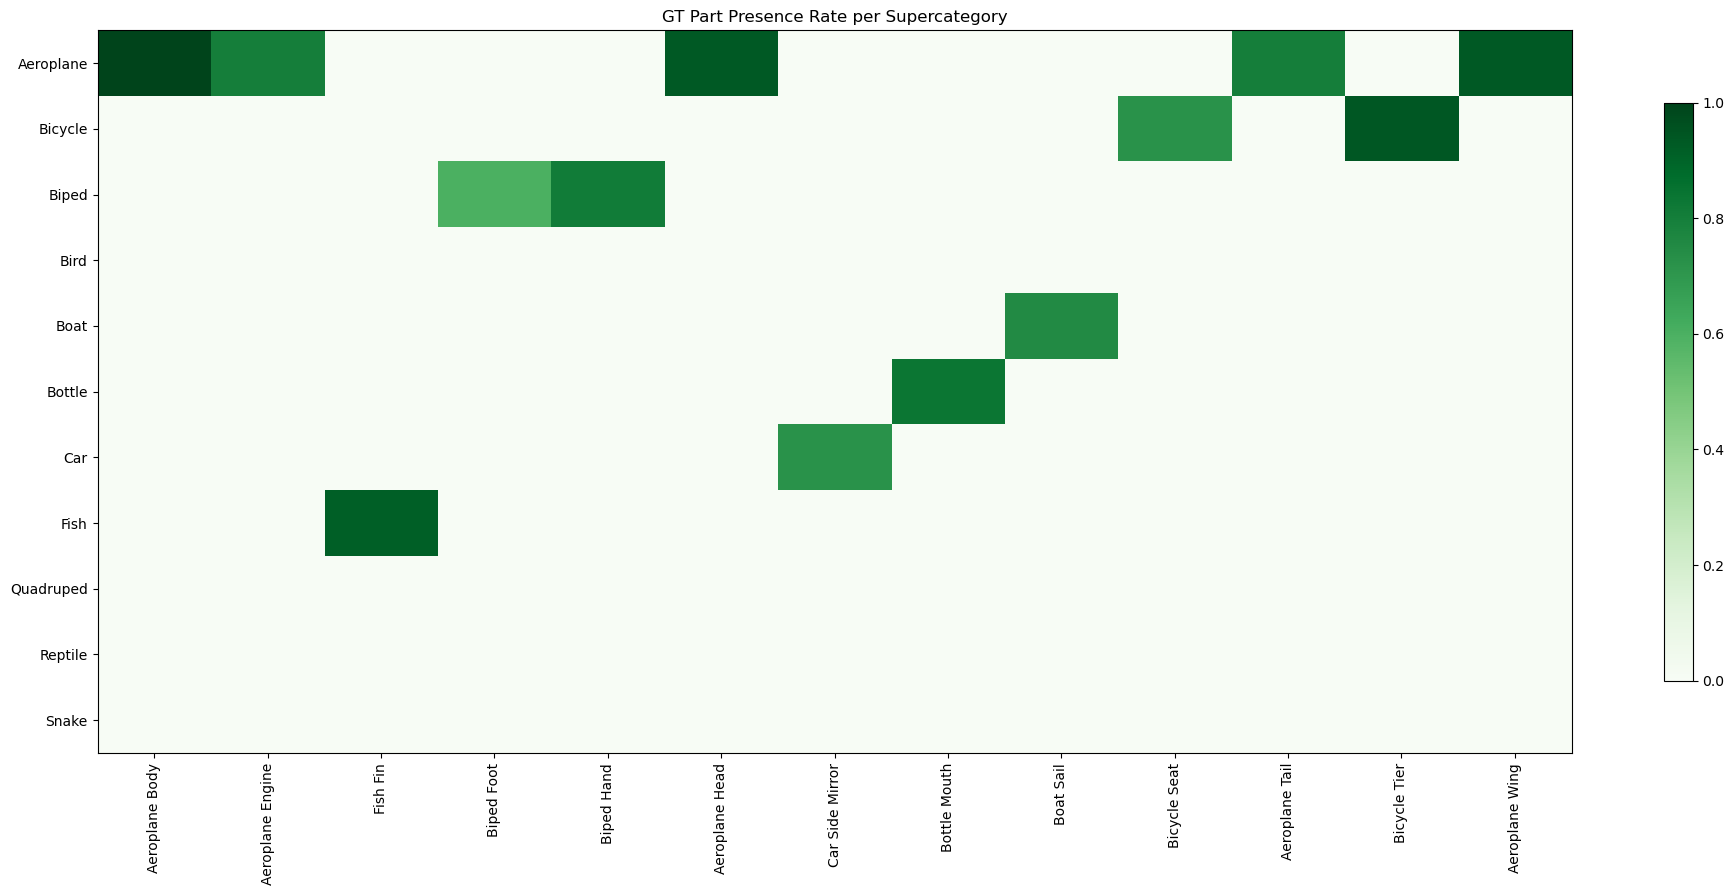

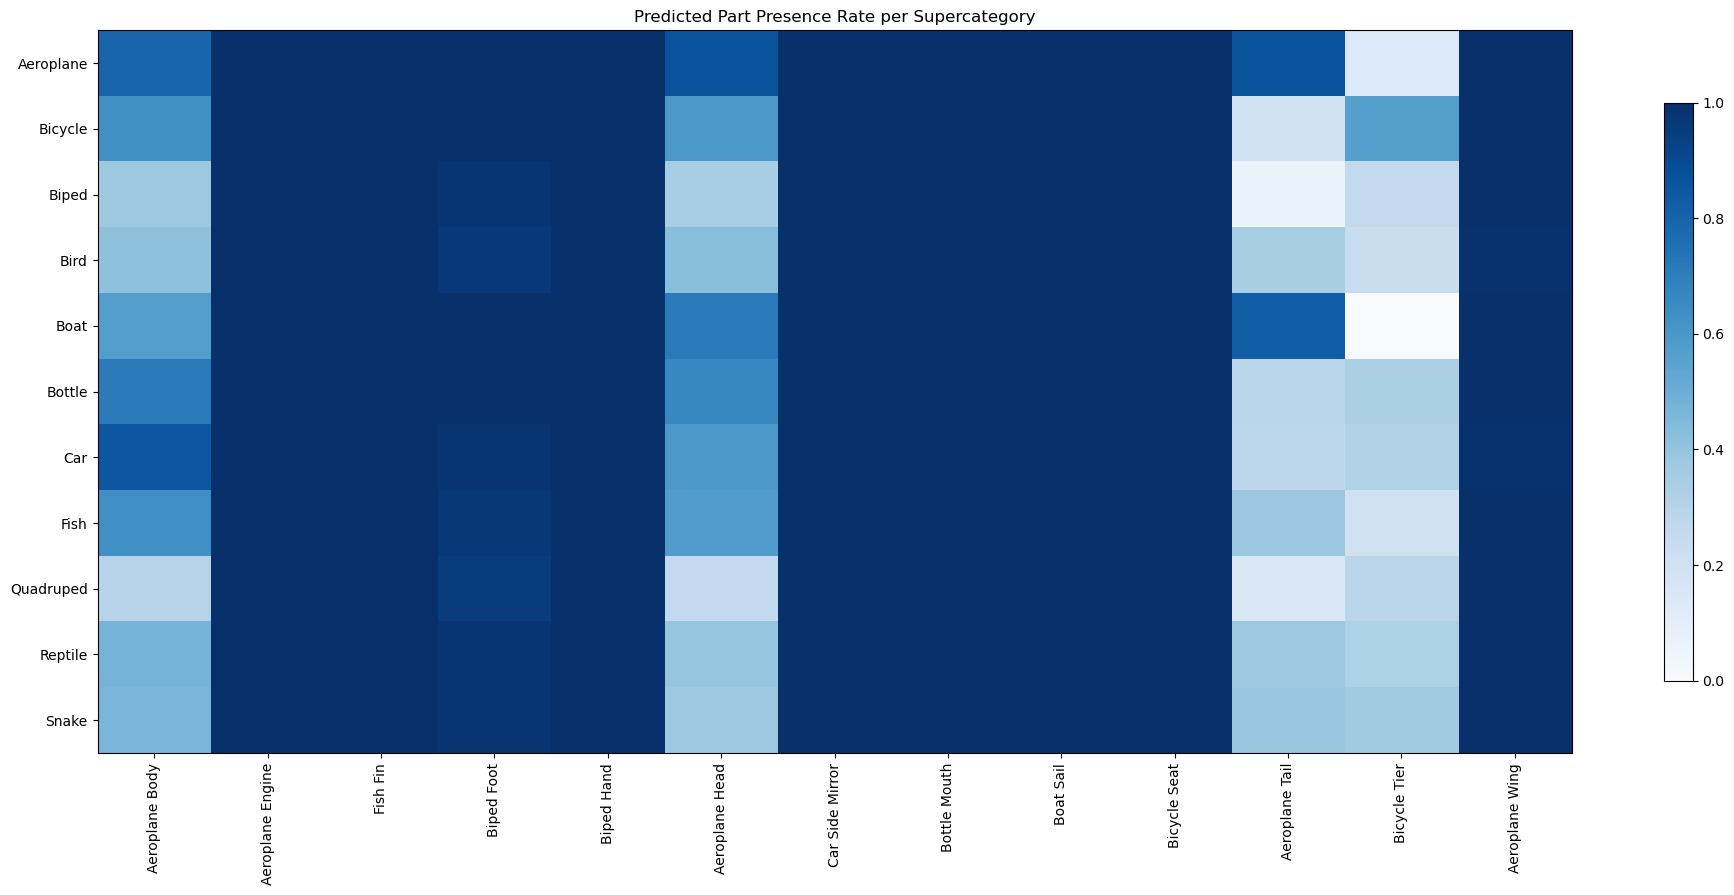

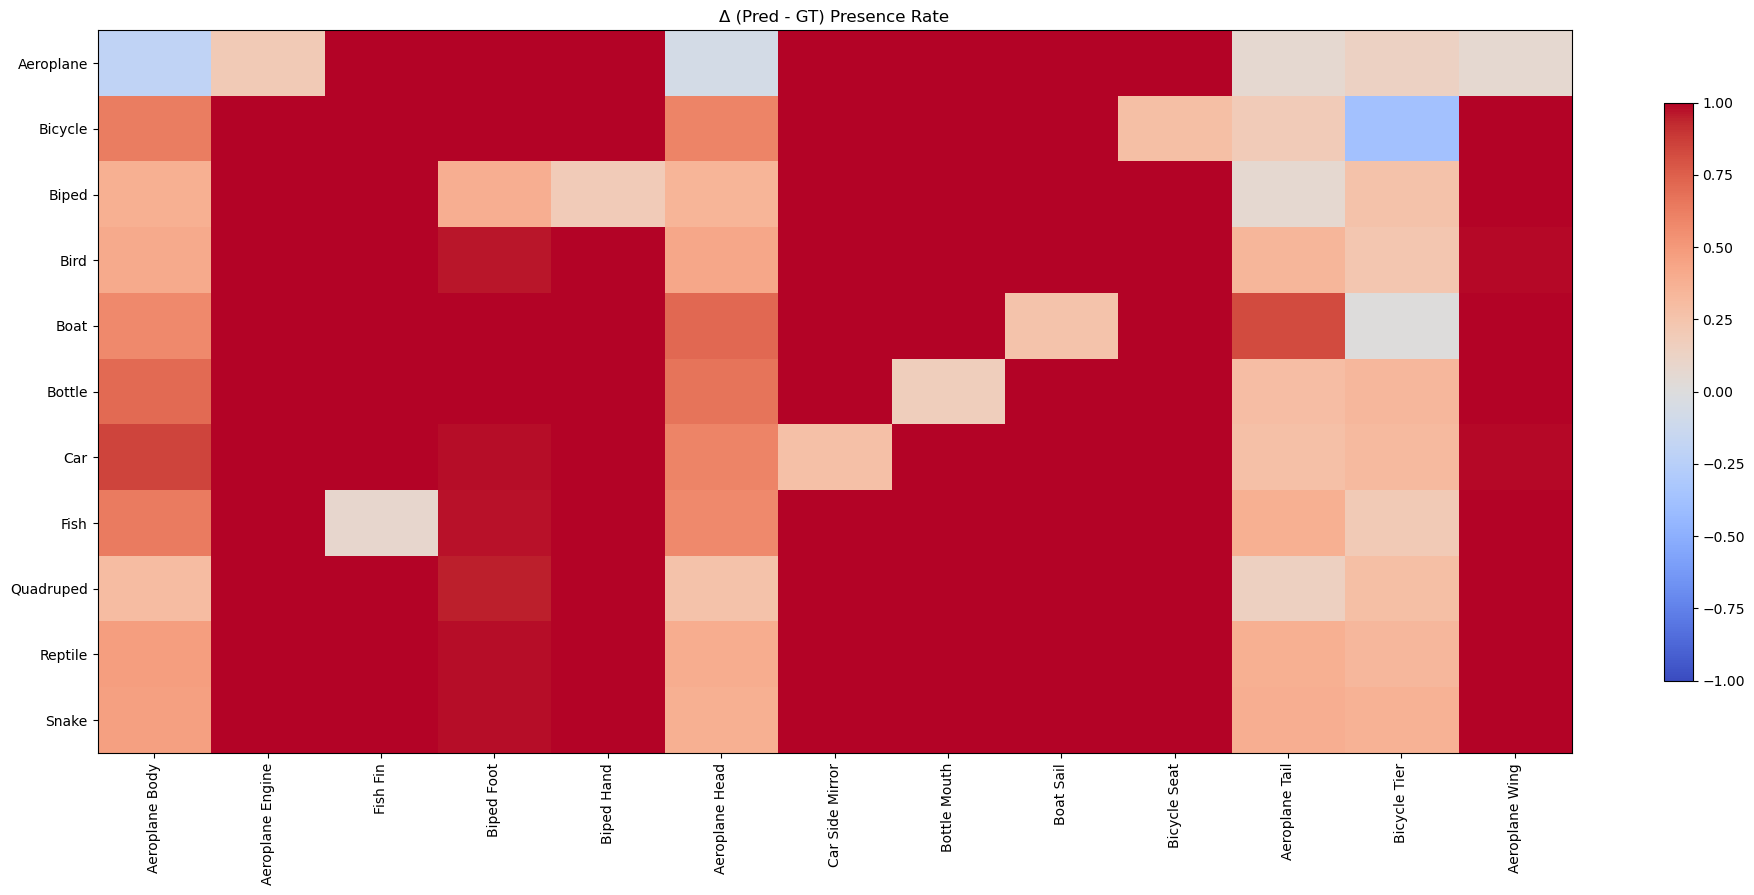

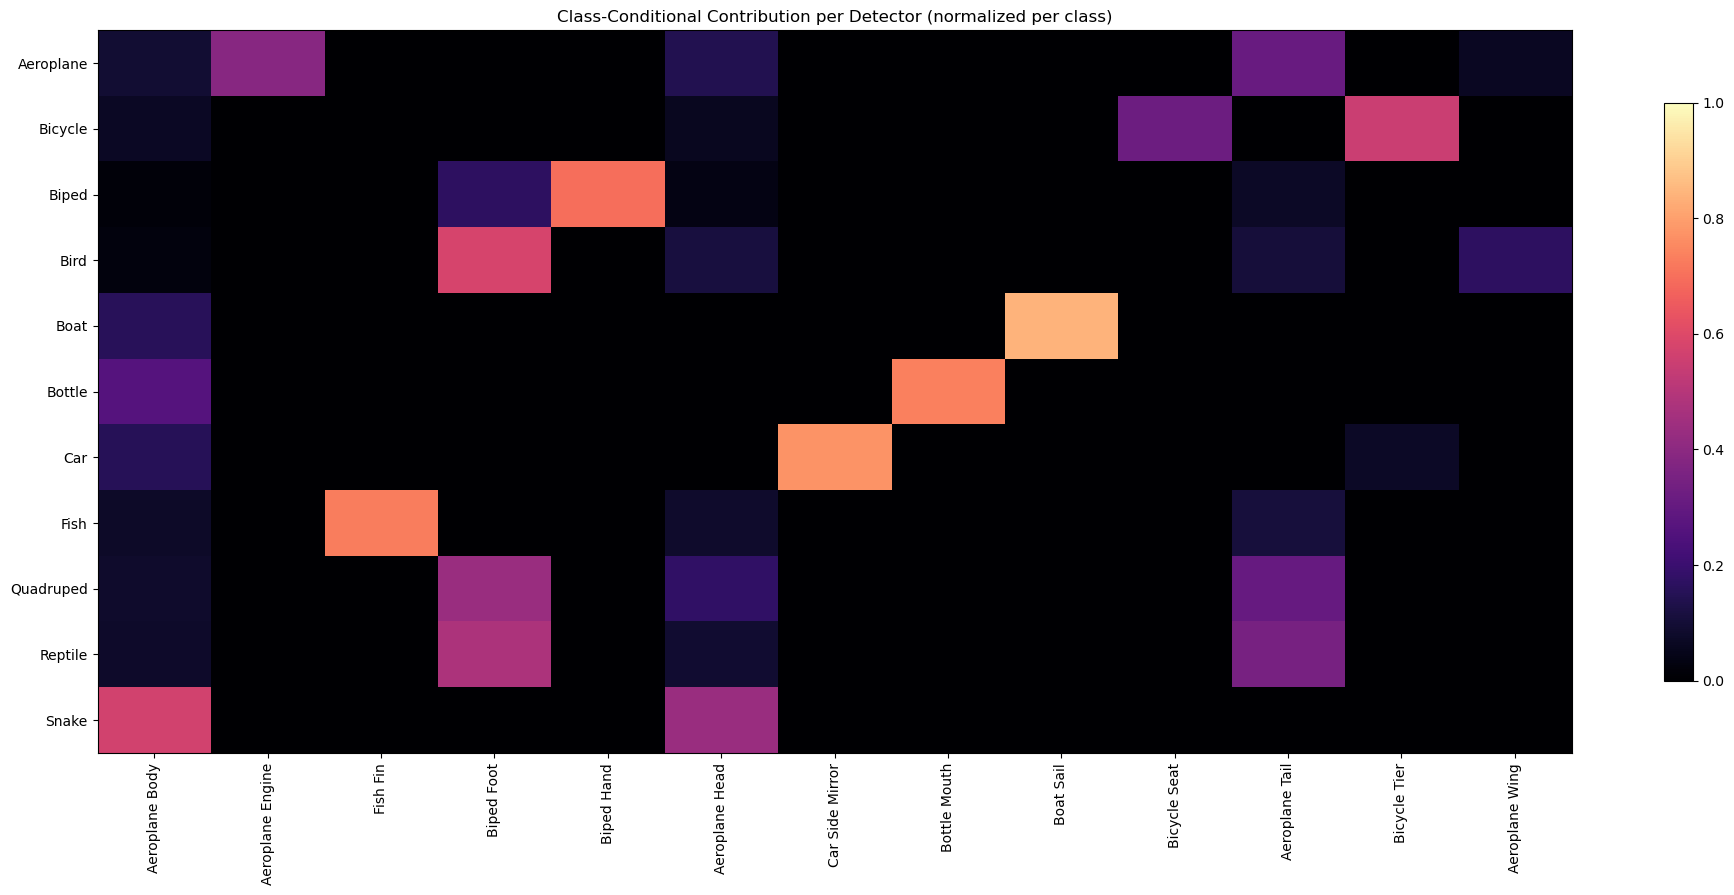

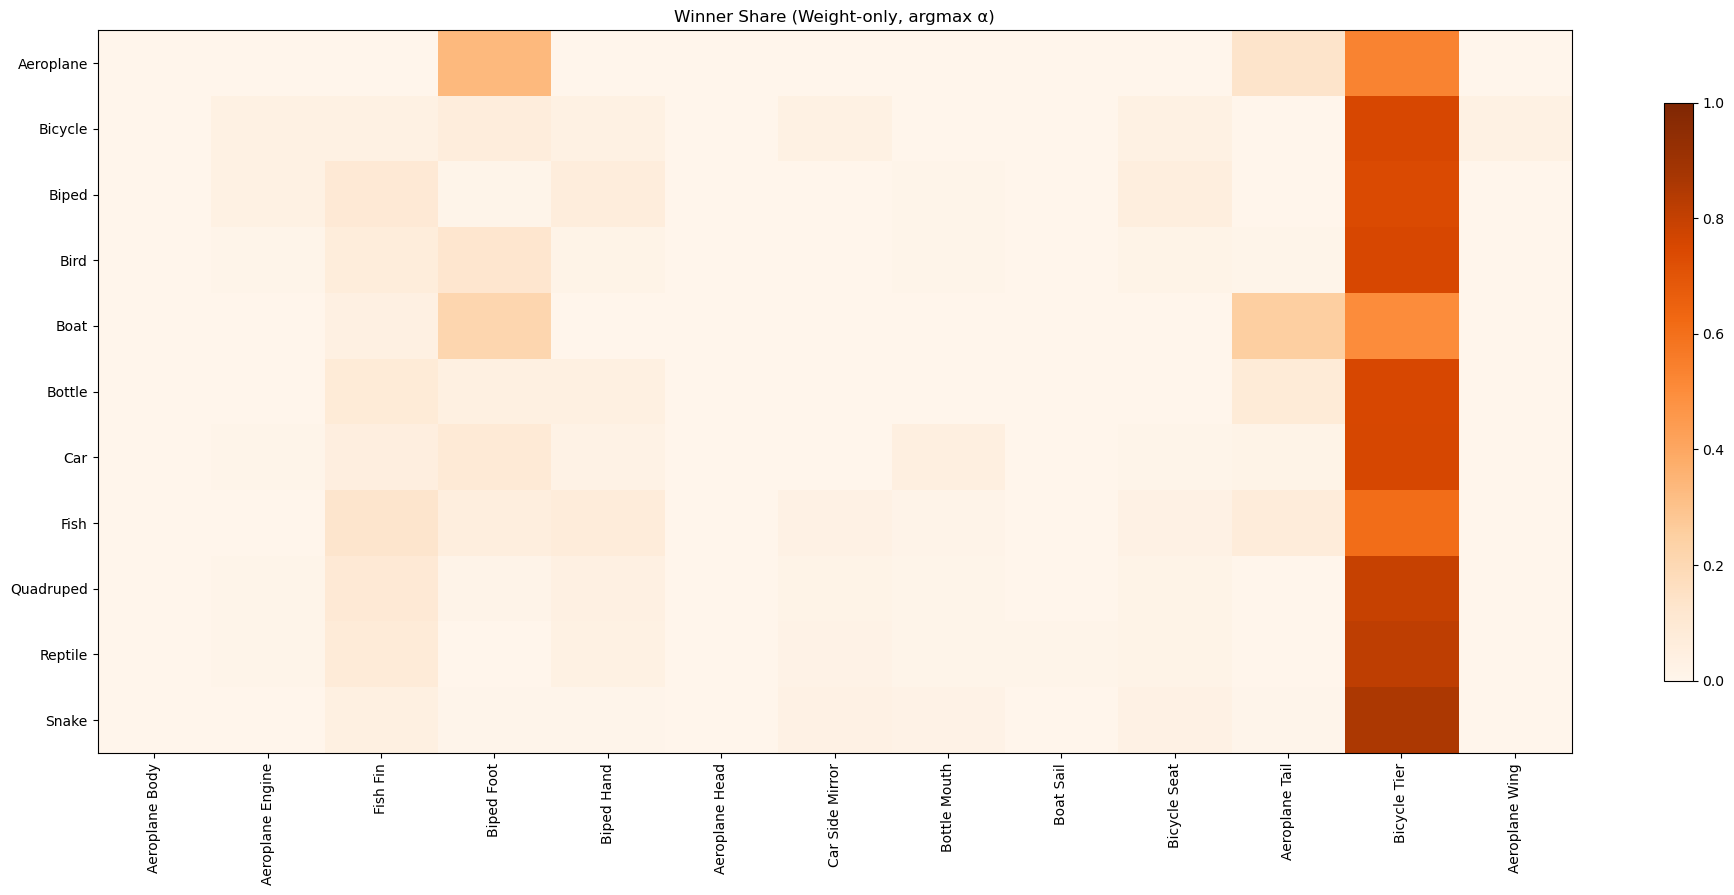

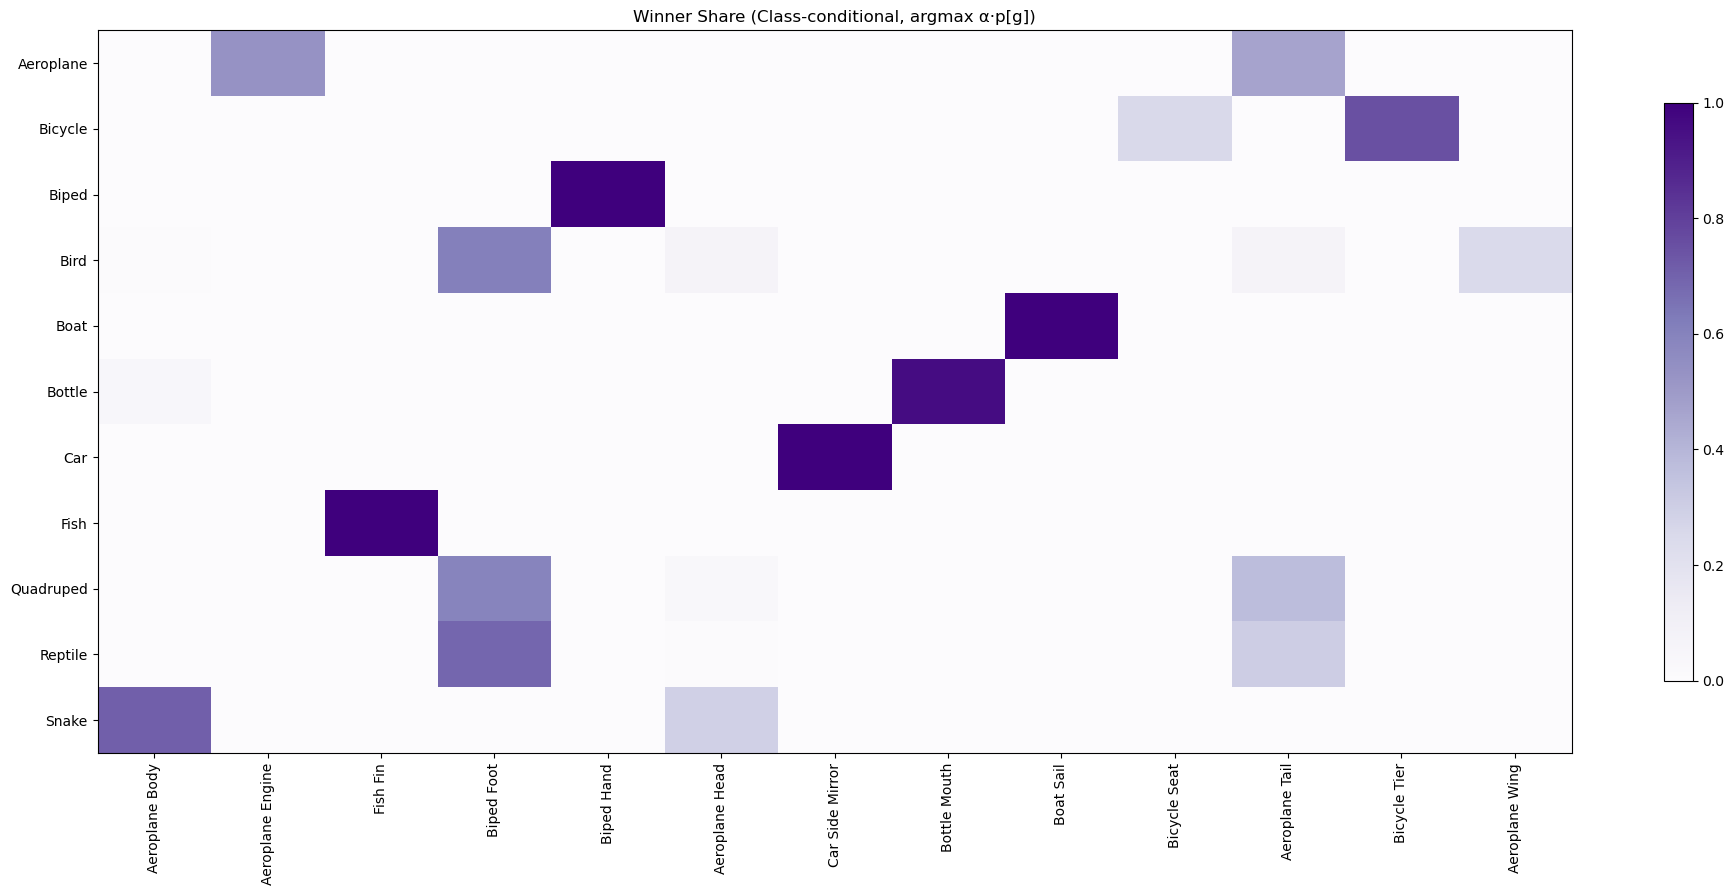

[Top parts for Aeroplane] Aeroplane Engine:0.39, Aeroplane Tail:0.31, Aeroplane Head:0.14, Aeroplane Body:0.09, Aeroplane Wing:0.06
[Top parts for Bicycle] Bicycle Tier:0.55, Bicycle Seat:0.32, Aeroplane Body:0.07, Aeroplane Head:0.06, Biped Foot:0.00
[Top parts for Biped] Biped Hand:0.70, Biped Foot:0.17, Aeroplane Tail:0.07, Aeroplane Head:0.04, Aeroplane Body:0.02
[Top parts for Bird] Biped Foot:0.58, Aeroplane Wing:0.17, Aeroplane Head:0.12, Aeroplane Tail:0.11, Aeroplane Body:0.02
[Top parts for Boat] Boat Sail:0.84, Aeroplane Body:0.16, Fish Fin:0.00, Aeroplane Engine:0.00, Biped Hand:0.00
[Top parts for Bottle] Bottle Mouth:0.74, Aeroplane Body:0.26, Fish Fin:0.00, Aeroplane Engine:0.00, Biped Foot:0.00
[Top parts for Car] Car Side Mirror:0.78, Aeroplane Body:0.15, Bicycle Tier:0.07, Fish Fin:0.00, Biped Foot:0.00
[Top parts for Fish] Fish Fin:0.73, Aeroplane Tail:0.11, Aeroplane Head:0.08, Aeroplane Body:0.08, Biped Foot:0.00
[Top parts for Quadruped] Biped Foot:0.43, Aeroplane

In [34]:
# === Cell G: plotting (plain Matplotlib; no seaborn) ===
det_labels = detector_to_partname
sup_labels = [IDX_TO_SUPER[g] for g in range(G)]

def plot_heatmap(mat, row_labels, col_labels, title, vmin=None, vmax=None, cmap="viridis"):
    plt.figure(figsize=(1.2*len(col_labels)+4, 0.55*len(row_labels)+3))
    im = plt.imshow(mat, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax, cmap=cmap)
    plt.colorbar(im, shrink=0.8)
    plt.xticks(ticks=np.arange(len(col_labels)), labels=col_labels, rotation=90)
    plt.yticks(ticks=np.arange(len(row_labels)), labels=row_labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Presence (GT / Pred / Delta)
plot_heatmap(GT,    sup_labels, det_labels, "GT Part Presence Rate per Supercategory", vmin=0, vmax=1, cmap="Greens")
plot_heatmap(PR,    sup_labels, det_labels, "Predicted Part Presence Rate per Supercategory", vmin=0, vmax=1, cmap="Blues")
plot_heatmap(DELTA, sup_labels, det_labels, "Δ (Pred - GT) Presence Rate", vmin=-1, vmax=1, cmap="coolwarm")

# Class-conditional contributions (column-normalized)
plot_heatmap(C_norm, sup_labels, det_labels, "Class-Conditional Contribution per Detector (normalized per class)", vmin=0, vmax=1, cmap="magma")

# Winners
plot_heatmap(W_wt, sup_labels, det_labels, "Winner Share (Weight-only, argmax α)", vmin=0, vmax=1, cmap="Oranges")
plot_heatmap(W_cc, sup_labels, det_labels, "Winner Share (Class-conditional, argmax α·p[g])", vmin=0, vmax=1, cmap="Purples")

# (Optional) top-5 contributing parts per class for captions
def topk_labels_per_class(mat, labels, k=5):
    out = []
    for g in range(mat.shape[0]):
        order = np.argsort(-mat[g])[:k]
        out.append([(labels[d], float(mat[g, d])) for d in order])
    return out

tops = topk_labels_per_class(C_norm, det_labels, k=5)
for g, t in enumerate(tops):
    print(f"[Top parts for {sup_labels[g]}] " + ", ".join([f"{n}:{v:.2f}" for n,v in t]))


In [35]:
# === Cell C′: STRICT local->global projection and clean detector labels ===
import re
from collections import Counter, defaultdict

# 1) Normalize GLOBAL_CLUSTERS so we can use its names as the authoritative set of parts
#    (handles either {name->id} or {id->name})
assert 'GLOBAL_CLUSTERS' in globals(), "GLOBAL_CLUSTERS must exist (mapping id<->part name)."

_gc = GLOBAL_CLUSTERS
if len(_gc) == 0:
    raise ValueError("GLOBAL_CLUSTERS is empty.")
first_k = next(iter(_gc.keys()))
if isinstance(first_k, str):
    GC_NAME2ID = dict(_gc)
    GC_ID2NAME = {v:k for k,v in GC_NAME2ID.items()}
elif isinstance(first_k, int):
    GC_ID2NAME = dict(_gc)
    GC_NAME2ID = {v:k for k,v in GC_ID2NAME.items()}
else:
    raise TypeError("GLOBAL_CLUSTERS keys must be str or int")

GC_NAMES = set(GC_NAME2ID.keys())  # authoritative vocabulary of part names

# 2) Canonical COCO category tables (name -> supercategory), restricted to GLOBAL_CLUSTERS names
CATID_TO_NAME  = {int(c["id"]): c["name"]          for c in val_coco["categories"]}
CATID_TO_SUPER = {int(c["id"]): c["supercategory"] for c in val_coco["categories"]}

# Filter to parts that exist in GLOBAL_CLUSTERS (avoid stray names)
COCO_CANON = {name: CATID_TO_SUPER[cid]
              for cid, name in CATID_TO_NAME.items() if name in GC_NAMES and CATID_TO_SUPER.get(cid) in SUPER_TO_IDX}
# Now we have canonical (part) name -> supercategory (string from COCO), aligned to GLOBAL_CLUSTERS

# 3) Normalization & tiny typo/synonym fixers (kept minimal on purpose)
_token_map = {
    # minimal, conservative fixes
    "tier": "tire",    # your log showed "Bicycle Tier" typo
    "tyre": "tire",
}
def _norm(s: str) -> str:
    s = s.lower()
    # token-level replacements
    toks = re.sub(r'[^a-z0-9]+', ' ', s).strip().split()
    toks = [_token_map.get(t, t) for t in toks]
    return " ".join(toks)

# Build normalized canonical lookups (restricted to GC_NAMES)
CANON_BY_NORM = {}        # norm_name -> (canonical_name, super_name, super_idx)
for cname, super_name in COCO_CANON.items():
    nn = _norm(cname)
    CANON_BY_NORM[nn] = (cname, super_name, SUPER_TO_IDX[super_name])

# 4) STRICT local->global projection per detector (exact normalized name → canonical only)
#    Anything unmatched gets -1 (ignored). We *do not* guess across families.
assert inv_clusters_list is not None and len(inv_clusters_list) > 0, "Need inv_clusters_list per detector"
D = len(inv_clusters_list)
G = len(SUPER_TO_IDX)

PROJ_IDX_CLEAN = []         # list[D] of LongTensor(Kd,) with global super idx or -1
LOCAL_CANON_NAME = []       # list[D] of dict local_idx -> canonical_name (or None)

for d in range(D):
    inv = inv_clusters_list[d]   # expected: dict local_idx -> local_name (string)
    # handle a few possible shapes robustly
    if isinstance(inv, dict):
        items = sorted(inv.items(), key=lambda kv: kv[0])
    elif isinstance(inv, list):
        items = list(enumerate(inv))
    else:
        raise TypeError(f"inv_clusters_list[{d}] must be dict or list")

    kd = len(items)
    proj = torch.full((kd,), -1, dtype=torch.long)
    local2canon = {}
    for k_local, local_name in items:
        nn = _norm(str(local_name))
        hit = CANON_BY_NORM.get(nn, None)
        if hit is None:
            # unmatched -> ignore
            local2canon[k_local] = None
            continue
        cname, super_name, gidx = hit
        proj[k_local] = int(gidx)
        local2canon[k_local] = cname
    PROJ_IDX_CLEAN.append(proj)
    LOCAL_CANON_NAME.append(local2canon)

# 5) Detector family (dominant supercategory) & clean label per detector
detector_family_idx = []
detector_to_partname = []   # clean, family-consistent labels for columns

for d in range(D):
    proj = PROJ_IDX_CLEAN[d].tolist()
    fams = [p for p in proj if p >= 0]
    if not fams:
        # fallback: unknown family
        detector_family_idx.append(None)
        detector_to_partname.append(f"Unknown[{d}]")
        continue
    fam = Counter(fams).most_common(1)[0][0]          # dominant super idx
    detector_family_idx.append(fam)
    fam_name = IDX_TO_SUPER[fam]

    # among mapped locals belonging to 'fam', choose the most frequent canonical *part* name as the detector label
    names_in_fam = []
    for k_local, cname in LOCAL_CANON_NAME[d].items():
        if cname is None: 
            continue
        # double-check the cname's family to avoid leakage
        if COCO_CANON.get(cname, None) == fam_name:
            names_in_fam.append(cname)
    if names_in_fam:
        label = Counter(names_in_fam).most_common(1)[0][0]
    else:
        label = f"{fam_name}:Unknown[{d}]"
    detector_to_partname.append(label)

print("[Projection] Built strict PROJ_IDX_CLEAN.")
print("[Labels]    Detector labels (first 10):", detector_to_partname[:10])

# 6) Quick coverage diagnostics
unmapped = []
for d in range(D):
    proj = PROJ_IDX_CLEAN[d].numpy()
    kd = proj.size
    frac_unmapped = float((proj < 0).sum()) / max(1, kd)
    unmapped.append(frac_unmapped)
print(f"[Coverage] mean unmapped locals per detector: {np.mean(unmapped):.2%} (lower is better)")


[Projection] Built strict PROJ_IDX_CLEAN.
[Labels]    Detector labels (first 10): ['Aeroplane Body', 'Aeroplane Engine', 'Fish Fin', 'Biped Foot', 'Biped Hand', 'Aeroplane Head', 'Car Side Mirror', 'Bottle Mouth', 'Boat Sail', 'Bicycle Seat']
[Coverage] mean unmapped locals per detector: 0.00% (lower is better)


In [40]:
COCO_CANON

{'Quadruped Head': 'Quadruped',
 'Quadruped Body': 'Quadruped',
 'Quadruped Foot': 'Quadruped',
 'Quadruped Tail': 'Quadruped',
 'Biped Head': 'Biped',
 'Biped Body': 'Biped',
 'Biped Hand': 'Biped',
 'Biped Foot': 'Biped',
 'Biped Tail': 'Biped',
 'Fish Head': 'Fish',
 'Fish Body': 'Fish',
 'Fish Fin': 'Fish',
 'Fish Tail': 'Fish',
 'Bird Head': 'Bird',
 'Bird Body': 'Bird',
 'Bird Wing': 'Bird',
 'Bird Foot': 'Bird',
 'Bird Tail': 'Bird',
 'Snake Head': 'Snake',
 'Snake Body': 'Snake',
 'Reptile Head': 'Reptile',
 'Reptile Body': 'Reptile',
 'Reptile Foot': 'Reptile',
 'Reptile Tail': 'Reptile',
 'Car Body': 'Car',
 'Car Tier': 'Car',
 'Car Side Mirror': 'Car',
 'Bicycle Body': 'Bicycle',
 'Bicycle Head': 'Bicycle',
 'Bicycle Seat': 'Bicycle',
 'Bicycle Tier': 'Bicycle',
 'Boat Body': 'Boat',
 'Boat Sail': 'Boat',
 'Aeroplane Head': 'Aeroplane',
 'Aeroplane Body': 'Aeroplane',
 'Aeroplane Engine': 'Aeroplane',
 'Aeroplane Wing': 'Aeroplane',
 'Aeroplane Tail': 'Aeroplane',
 'Bottle M

In [36]:
# === Cell E′: recompute per-detector global probabilities with strict projection ===
@torch.no_grad()
def compute_pG_list_strict(ens, xb: torch.Tensor) -> List[torch.Tensor]:
    """
    Project each detector's local probabilities to the global supercategory space
    using PROJ_IDX_CLEAN (strict mapping). Unmapped locals (-1) contribute nothing.
    Returns list[D] of tensors (B,G).
    """
    try:
        zs_list, logits_list = ens.score_all(xb, channels_last=True)
    except TypeError:
        zs_list, logits_list = ens.score_all(xb)

    D = len(zs_list)
    G = len(SUPER_TO_IDX)
    B = zs_list[0].size(0)
    out = []
    for d in range(D):
        lg = logits_list[d]
        if (lg is not None) and (lg.size(1) >= 2):
            p_local = F.softmax(lg.float(), dim=1)     # (B,Kd)
        else:
            p_local = torch.ones(B, 1, device=xb.device, dtype=torch.float32)

        idx = PROJ_IDX_CLEAN[d].to(xb.device)         # (Kd,)
        pG = torch.zeros(B, G, device=xb.device, dtype=torch.float32)
        valid = (idx >= 0)
        if valid.any():
            pG.index_add_(1, idx[valid], p_local[:, valid])
        out.append(pG)
    return out

# Re-run the *one* val pass to refresh per-detector pG with the strict projection.
all_ids, all_y = [], []
all_attn, all_confs = [], []
per_det_pG = [ [] for _ in range(D) ]

with torch.no_grad():
    fuser.eval()
    for xb, yb, meta in dl_img:
        xb = xb.to(device, non_blocking=True)
        probs, attn_w, dbg = fuser.fuse_from_ensemble(ens, xb, no_grad_ensemble=True, detach_ensemble=True)
        confs = dbg.get("confs", None)
        if confs is None:
            # fall back to computing confidences from ensemble outputs (unchanged from your previous cell)
            try:
                zs_list, logits_list = ens.score_all(xb)
            except TypeError:
                zs_list, logits_list = ens.score_all(xb)
            confs_row = []
            for d in range(D):
                lg = logits_list[d]
                if (lg is not None) and (lg.size(1) >= 2):
                    confs_row.append(F.softmax(lg, dim=1).max(dim=1).values.unsqueeze(1))
                else:
                    z = zs_list[d]
                    ctr = getattr(ens, "centers", [None]*D)[d]
                    var = getattr(ens, "vars",    [None]*D)[d]
                    d2 = ((z - (ctr.unsqueeze(0) if ctr is not None else 0))**2 / ((var.unsqueeze(0) if var is not None else 1)+1e-6)).sum(1)
                    confs_row.append(torch.exp(-0.5*d2).unsqueeze(1))
            confs = torch.cat(confs_row, dim=1)

        # **Use the strict projector here**
        pG_list = compute_pG_list_strict(ens, xb)

        # meta normalization is unchanged: use your earlier _normalize_meta_to_ids(meta, xb.size(0))
        batch_ids = _normalize_meta_to_ids(meta, xb.size(0))
        all_ids.extend(batch_ids)
        all_y.extend(yb.tolist())
        all_attn.append(attn_w.detach().cpu())
        all_confs.append(confs.detach().cpu())
        for d in range(D):
            per_det_pG[d].append(pG_list[d].detach().cpu())

# Stack
all_y = torch.tensor(all_y, dtype=torch.long)
all_attn = torch.cat(all_attn, 0)
all_confs = torch.cat(all_confs, 0)
for d in range(D):
    per_det_pG[d] = torch.cat(per_det_pG[d], 0)

print("Recollected with strict projection:",
      "N=", len(all_ids),
      "attn", tuple(all_attn.shape),
      "confs", tuple(all_confs.shape),
      "pG[0]", tuple(per_det_pG[0].shape))


/home/dfli/full_hyco/part_detector_refactor.py:996: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(self.device.type=="cuda")):


Recollected with strict projection: N= 1205 attn (1205, 13) confs (1205, 13) pG[0] (1205, 11)


In [37]:
# === Cell F: thresholds, GT/Pred presence matrices, contributions, winners ===

# GT presence per image per detector (via canonical part names)
gt_presence = torch.zeros(len(all_ids), D, dtype=torch.bool)
for n, iid in enumerate(all_ids):
    present = IMGID_TO_PARTNAMES.get(int(iid), set())
    for d in range(D):
        gt_presence[n, d] = (detector_to_partname[d] in present)

# Per-detector presence scores (use confs from fuser)
scores = all_confs.clone()

def _youdens_j(pos: torch.Tensor, neg: torch.Tensor) -> float:
    if pos.numel()==0 or neg.numel()==0:
        comb = torch.cat([pos, neg], 0)
        return float(comb.median().item()) if comb.numel() else 0.5
    cand = torch.sort(torch.unique(torch.cat([pos, neg]))).values
    best, best_t = -1e9, float(cand[0].item())
    for t in cand:
        t = float(t.item())
        tpr = (pos >= t).float().mean().item()
        fpr = (neg >= t).float().mean().item()
        j = tpr - fpr
        if j > best:
            best, best_t = j, t
    return best_t

# Threshold per detector
theta = np.zeros(D, dtype=np.float32)
for d in range(D):
    pos = scores[gt_presence[:, d], d]
    neg = scores[~gt_presence[:, d], d]
    theta[d] = _youdens_j(pos, neg)
print("Per-detector thresholds (first 10):", np.round(theta[:10], 3))

# Build matrices
N = len(all_ids); G = len(SUPER_TO_IDX)
y = all_y.clone()
attn = all_attn.clone().float()
pG = [x.clone().float() for x in per_det_pG]

# 1) GT/Pred presence per supercategory
GT = np.zeros((G, D), dtype=np.float32)
PR = np.zeros((G, D), dtype=np.float32)
for g in range(G):
    idx = (y == g).nonzero().view(-1)
    if idx.numel() == 0: 
        continue
    GT[g, :] = gt_presence[idx].float().mean(dim=0).numpy()
    pred_bin = (scores[idx, :] >= torch.tensor(theta).view(1, D)).float()
    PR[g, :] = pred_bin.mean(dim=0).numpy()
DELTA = PR - GT

# 2) Class-conditional contribution C(g,d) = E[ α_d · p^{(d)}_g | y==g ]
C = np.zeros((G, D), dtype=np.float32)
for g in range(G):
    idx = (y == g).nonzero().view(-1)
    if idx.numel() == 0: 
        continue
    for d in range(D):
        C[g, d] = (attn[idx, d] * pG[d][idx, g]).mean().item()
C_norm = C / np.clip(C.sum(axis=1, keepdims=True), 1e-6, None)

# 3) Winners
wt_winner = torch.argmax(attn, dim=1).cpu().numpy()
contrib = torch.zeros(N, D)
for d in range(D):
    contrib[:, d] = attn[:, d] * pG[d][torch.arange(N), y]
cc_winner = torch.argmax(contrib, dim=1).cpu().numpy()

W_wt = np.zeros((G, D), dtype=np.float32)
W_cc = np.zeros((G, D), dtype=np.float32)
for g in range(G):
    idx = np.where(y.numpy() == g)[0]
    if len(idx) == 0: 
        continue
    for d in range(D):
        W_wt[g, d] = float((wt_winner[idx] == d).mean())
        W_cc[g, d] = float((cc_winner[idx] == d).mean())

print("Matrices -> GT, PR, Δ, C_norm, W_wt, W_cc:", GT.shape, PR.shape, DELTA.shape, C_norm.shape, W_wt.shape, W_cc.shape)


Per-detector thresholds (first 10): [0.314 0.    0.    0.136 0.    0.368 0.    0.    0.    0.   ]
Matrices -> GT, PR, Δ, C_norm, W_wt, W_cc: (11, 13) (11, 13) (11, 13) (11, 13) (11, 13) (11, 13)


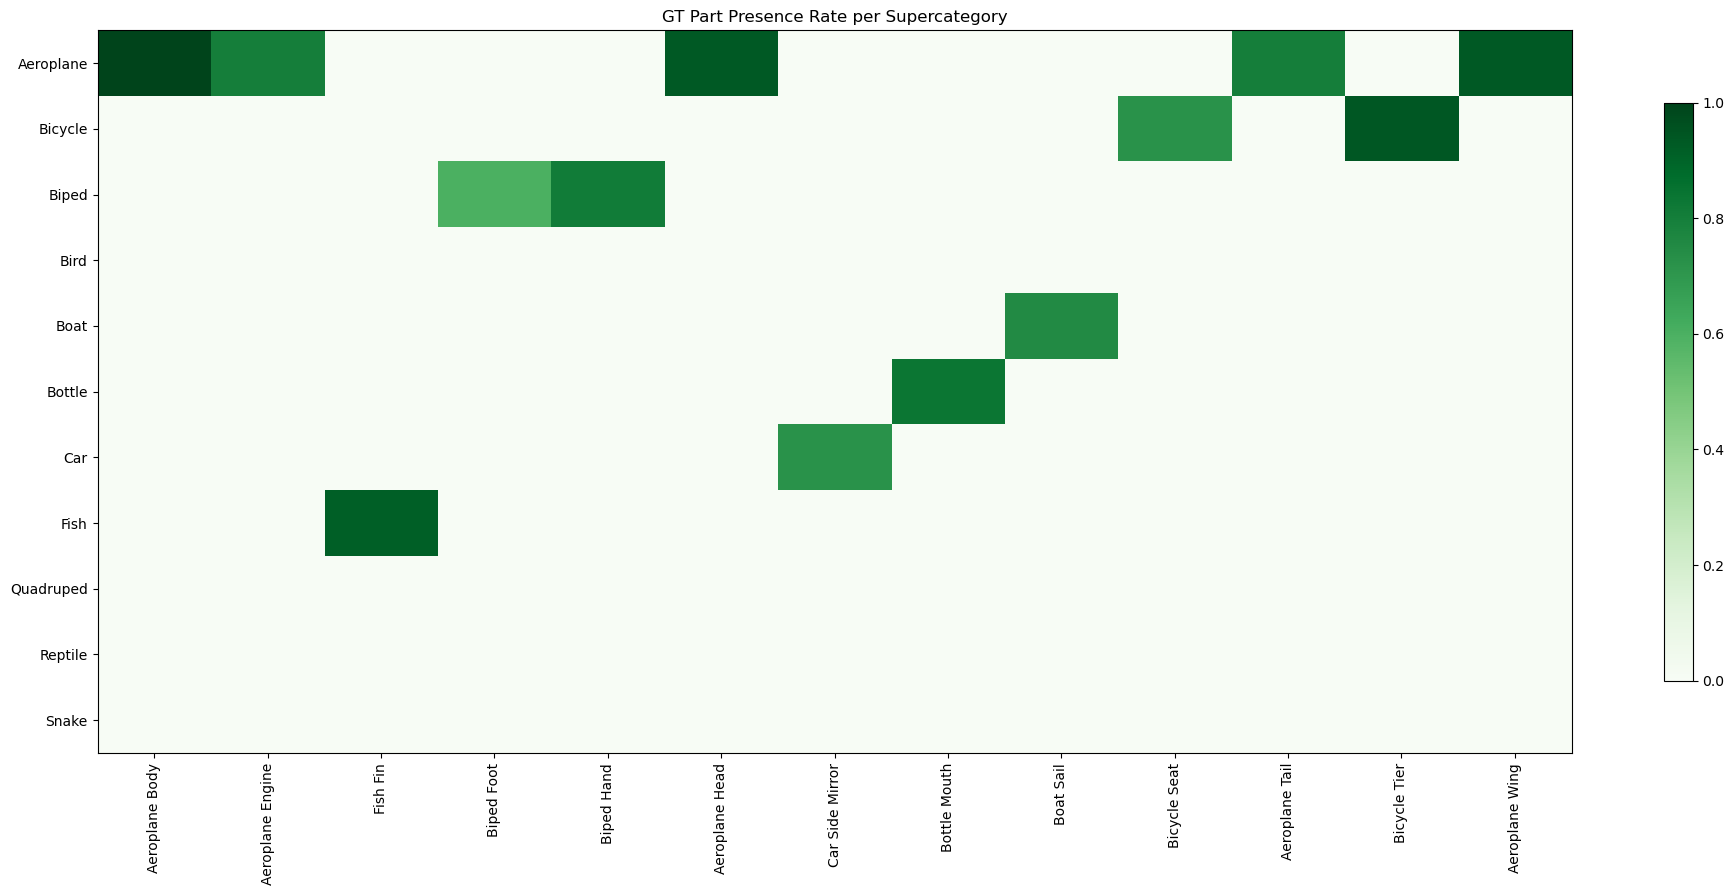

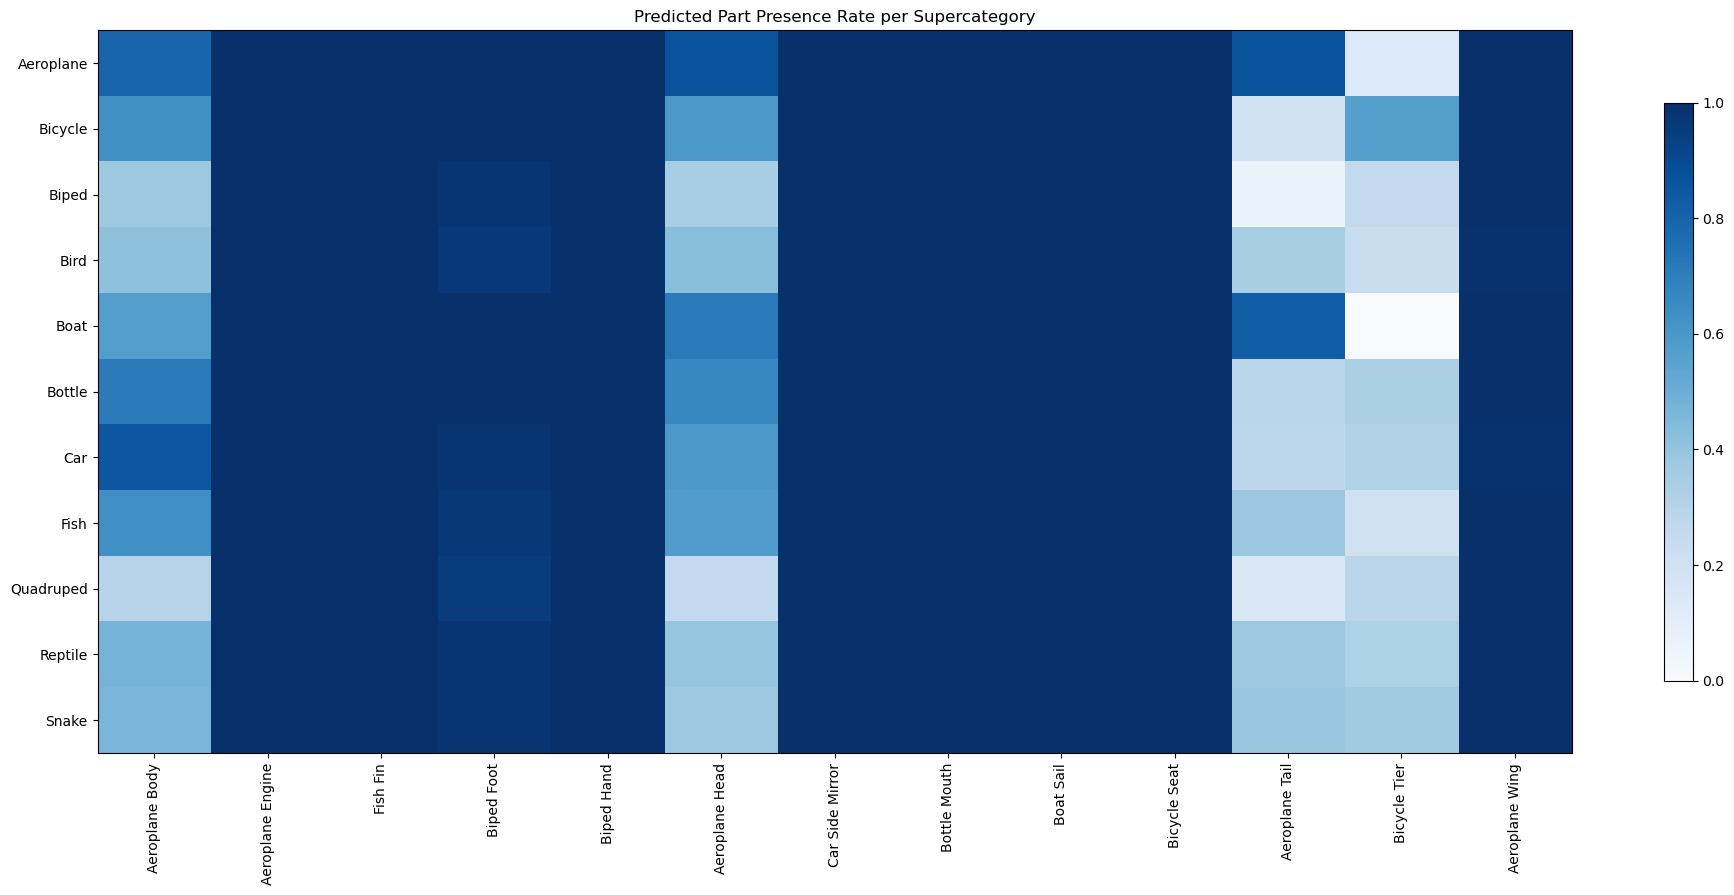

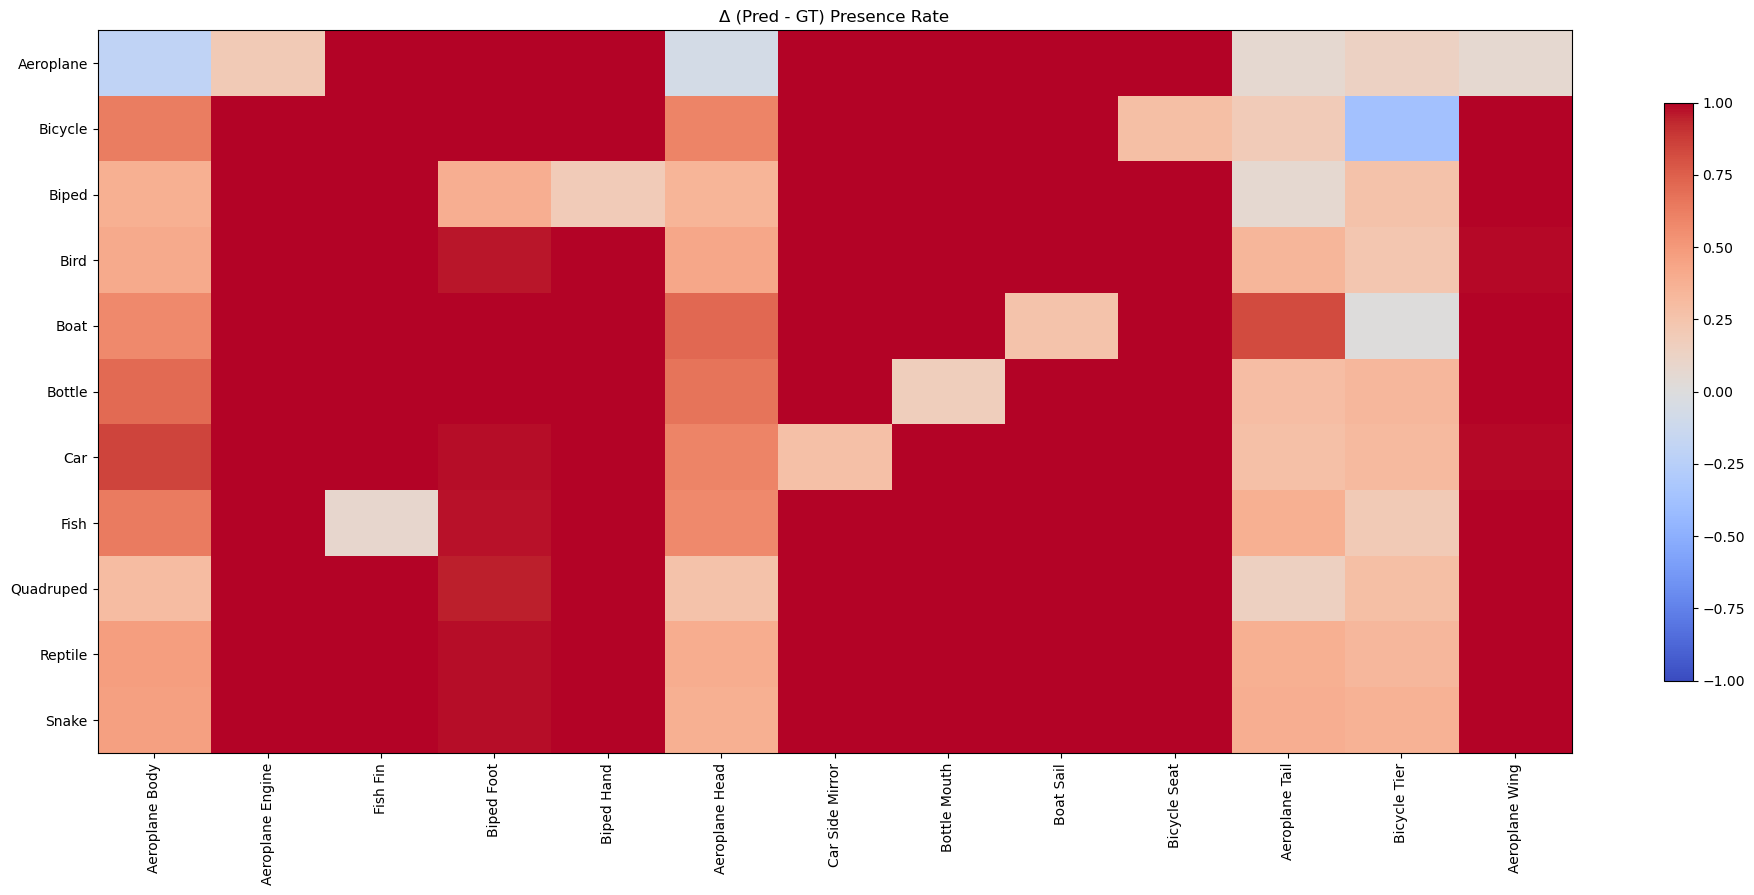

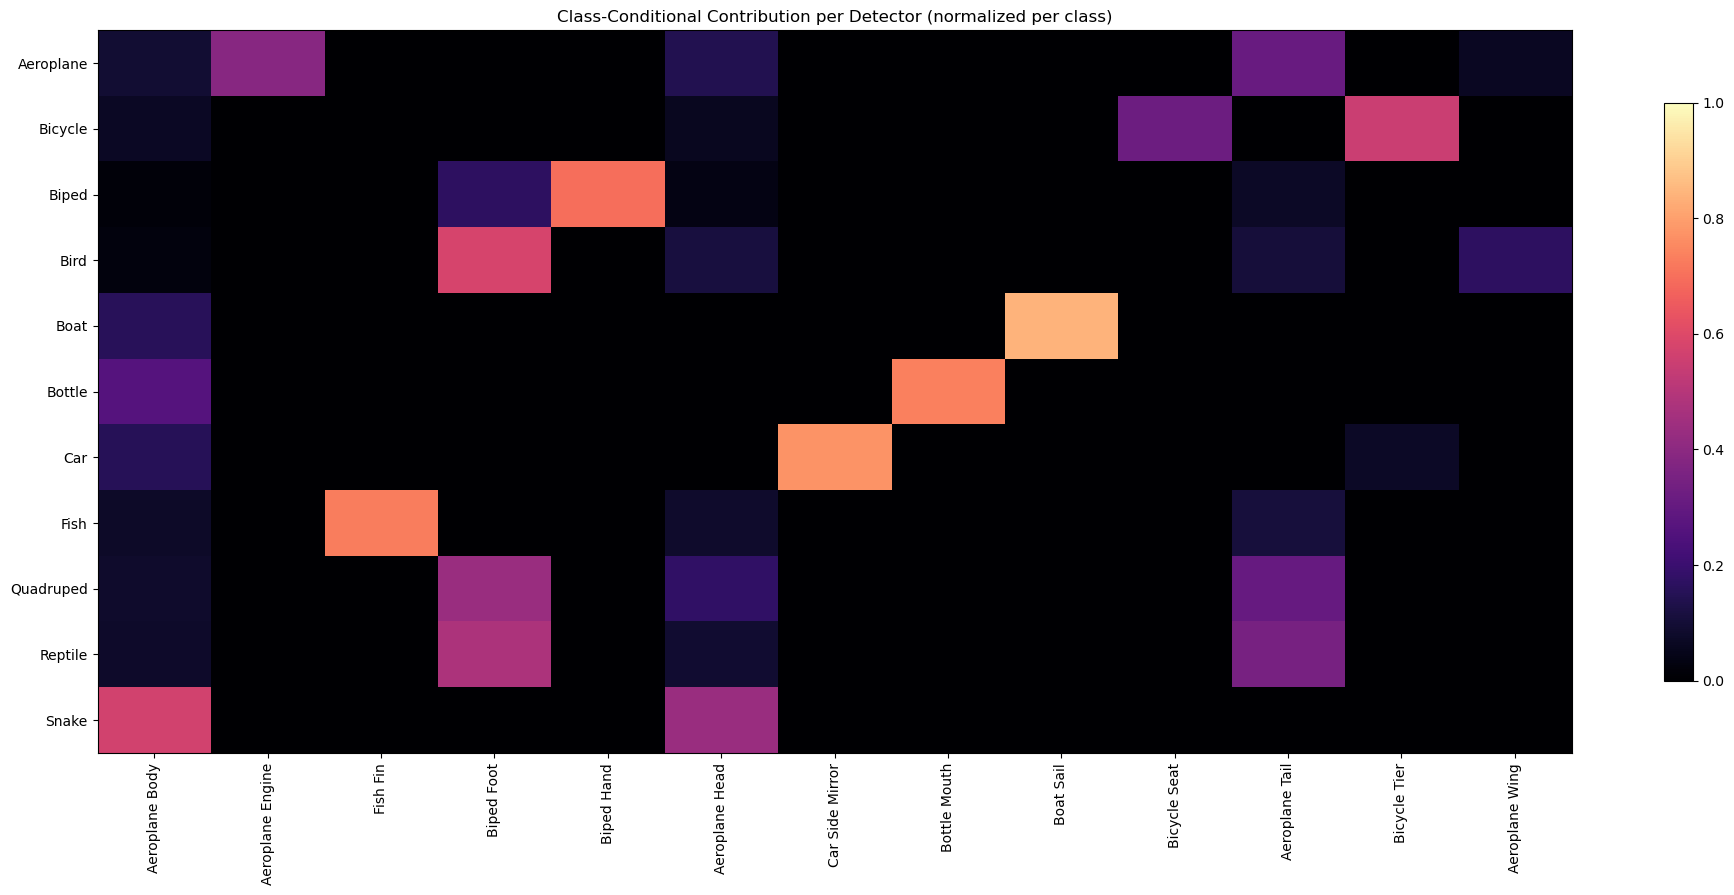

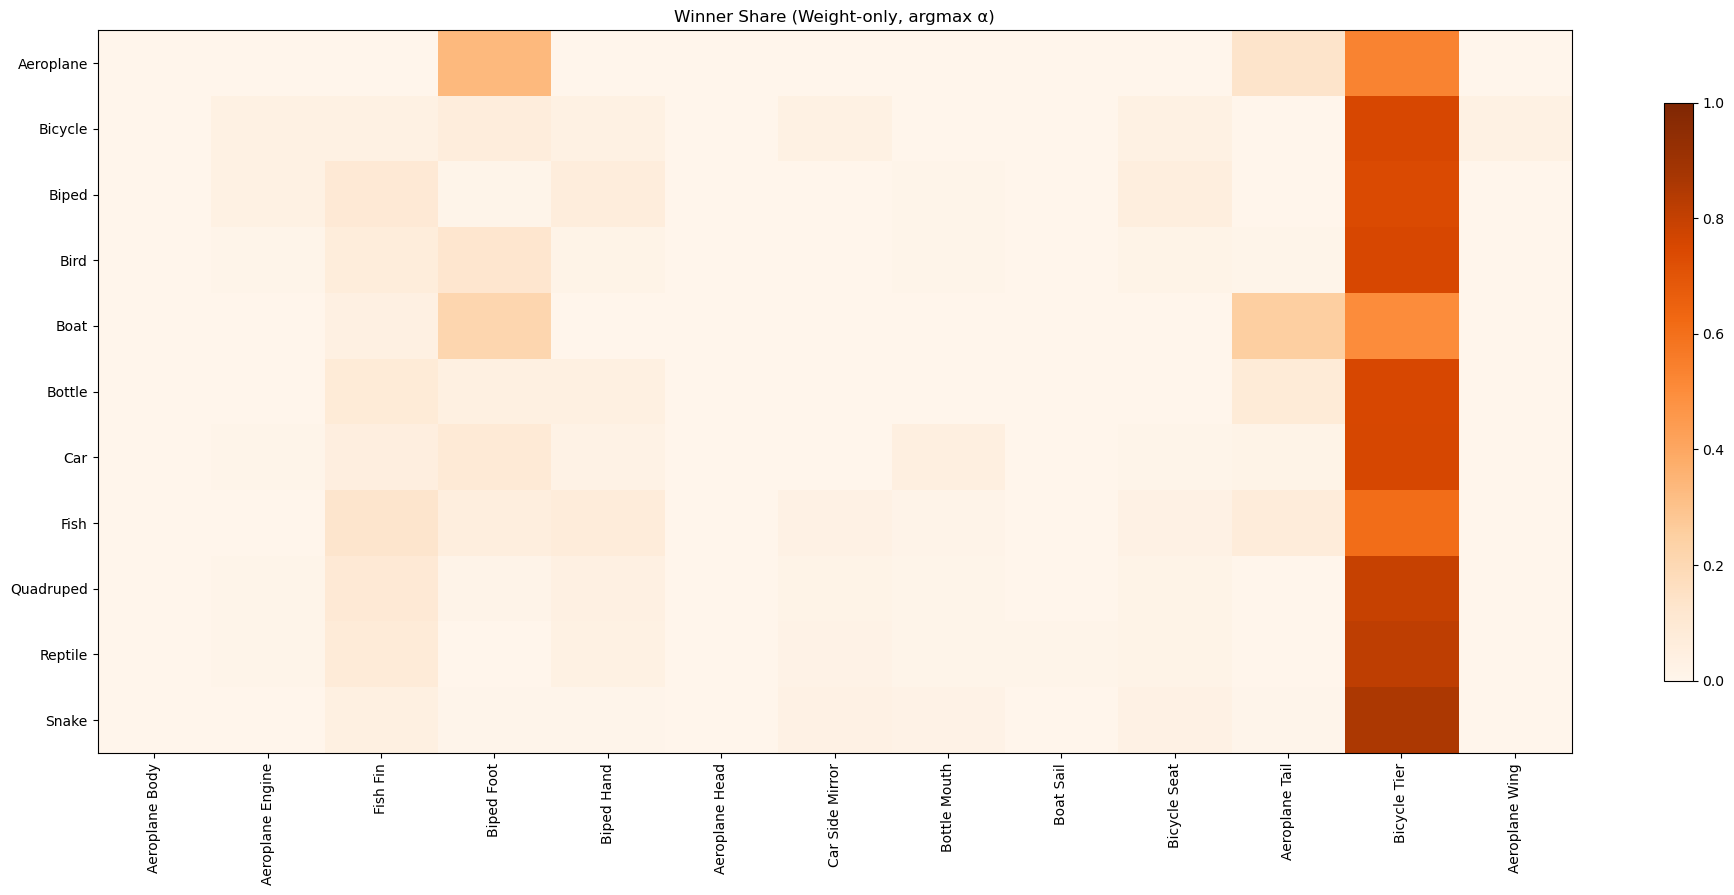

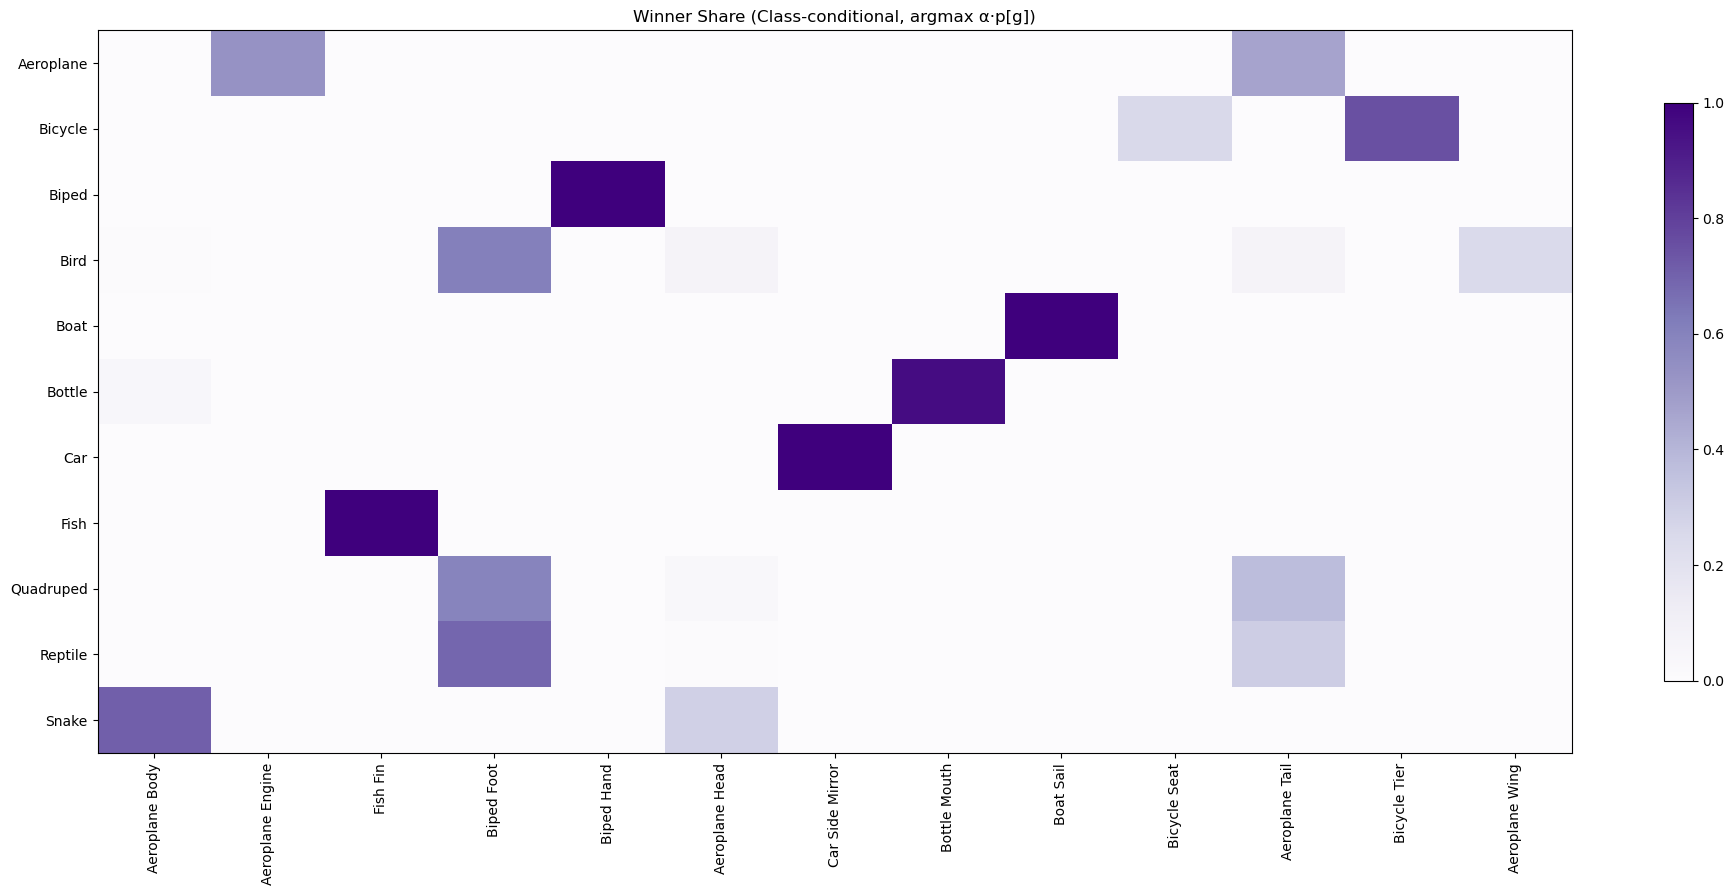

[Top parts for Aeroplane] Aeroplane Engine:0.39, Aeroplane Tail:0.31, Aeroplane Head:0.14, Aeroplane Body:0.09, Aeroplane Wing:0.06
[Top parts for Bicycle] Bicycle Tier:0.55, Bicycle Seat:0.32, Aeroplane Body:0.07, Aeroplane Head:0.06, Biped Foot:0.00
[Top parts for Biped] Biped Hand:0.70, Biped Foot:0.17, Aeroplane Tail:0.07, Aeroplane Head:0.04, Aeroplane Body:0.02
[Top parts for Bird] Biped Foot:0.58, Aeroplane Wing:0.17, Aeroplane Head:0.12, Aeroplane Tail:0.11, Aeroplane Body:0.02
[Top parts for Boat] Boat Sail:0.84, Aeroplane Body:0.16, Fish Fin:0.00, Aeroplane Engine:0.00, Biped Hand:0.00
[Top parts for Bottle] Bottle Mouth:0.74, Aeroplane Body:0.26, Fish Fin:0.00, Aeroplane Engine:0.00, Biped Foot:0.00
[Top parts for Car] Car Side Mirror:0.78, Aeroplane Body:0.15, Bicycle Tier:0.07, Fish Fin:0.00, Biped Foot:0.00
[Top parts for Fish] Fish Fin:0.73, Aeroplane Tail:0.11, Aeroplane Head:0.08, Aeroplane Body:0.08, Biped Foot:0.00
[Top parts for Quadruped] Biped Foot:0.43, Aeroplane

In [ ]:
# === Cell G: plotting (plain Matplotlib; no seaborn) ===
det_labels = detector_to_partname
sup_labels = [IDX_TO_SUPER[g] for g in range(G)]

def plot_heatmap(mat, row_labels, col_labels, title, vmin=None, vmax=None, cmap="viridis"):
    plt.figure(figsize=(1.2*len(col_labels)+4, 0.55*len(row_labels)+3))
    im = plt.imshow(mat, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax, cmap=cmap)
    plt.colorbar(im, shrink=0.8)
    plt.xticks(ticks=np.arange(len(col_labels)), labels=col_labels, rotation=90)
    plt.yticks(ticks=np.arange(len(row_labels)), labels=row_labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Presence (GT / Pred / Delta)
plot_heatmap(GT,    sup_labels, det_labels, "GT Part Presence Rate per Supercategory", vmin=0, vmax=1, cmap="Greens")
plot_heatmap(PR,    sup_labels, det_labels, "Predicted Part Presence Rate per Supercategory", vmin=0, vmax=1, cmap="Blues")
plot_heatmap(DELTA, sup_labels, det_labels, "Δ (Pred - GT) Presence Rate", vmin=-1, vmax=1, cmap="coolwarm")

# Class-conditional contributions (column-normalized)
plot_heatmap(C_norm, sup_labels, det_labels, "Class-Conditional Contribution per Detector (normalized per class)", vmin=0, vmax=1, cmap="magma")

# Winners
# plot_heatmap(W_wt, sup_labels, det_labels, "Winner Share (Weight-only, argmax α)", vmin=0, vmax=1, cmap="Oranges")
plot_heatmap(W_cc, sup_labels, det_labels, "Winner Share (Class-conditional, argmax α·p[g])", vmin=0, vmax=1, cmap="Purples")

# (Optional) top-5 contributing parts per class for captions
def topk_labels_per_class(mat, labels, k=5):
    out = []
    for g in range(mat.shape[0]):
        order = np.argsort(-mat[g])[:k]
        out.append([(labels[d], float(mat[g, d])) for d in order])
    return out

tops = topk_labels_per_class(C_norm, det_labels, k=5)
for g, t in enumerate(tops):
    print(f"[Top parts for {sup_labels[g]}] " + ", ".join([f"{n}:{v:.2f}" for n,v in t]))


In [39]:
GLOBAL_CLUSTERS

{'Aeroplane Body': 0,
 'Aeroplane Engine': 1,
 'Aeroplane Head': 2,
 'Aeroplane Tail': 3,
 'Aeroplane Wing': 4,
 'Bicycle Body': 5,
 'Bicycle Head': 6,
 'Bicycle Seat': 7,
 'Bicycle Tier': 8,
 'Biped Body': 9,
 'Biped Foot': 10,
 'Biped Hand': 11,
 'Biped Head': 12,
 'Biped Tail': 13,
 'Bird Body': 14,
 'Bird Foot': 15,
 'Bird Head': 16,
 'Bird Tail': 17,
 'Bird Wing': 18,
 'Boat Body': 19,
 'Boat Sail': 20,
 'Bottle Body': 21,
 'Bottle Mouth': 22,
 'Car Body': 23,
 'Car Side Mirror': 24,
 'Car Tier': 25,
 'Fish Body': 26,
 'Fish Fin': 27,
 'Fish Head': 28,
 'Fish Tail': 29,
 'Quadruped Body': 30,
 'Quadruped Foot': 31,
 'Quadruped Head': 32,
 'Quadruped Tail': 33,
 'Reptile Body': 34,
 'Reptile Foot': 35,
 'Reptile Head': 36,
 'Reptile Tail': 37,
 'Snake Body': 38,
 'Snake Head': 39}